In [66]:
%load_ext cuml.accel
# %run /workspace/alvin/SAR_ML/notebooks/SSR/SSRtransforms_preloaded.py
%run /mnt/d/Users/Admin/Projects/dso/SAR_ML/notebooks/SSR/SSRtransforms_preloaded.py
import os
import re
import copy
import random
from collections import defaultdict
from joblib import Parallel, delayed
from tqdm import tqdm
import pickle
import time

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors
from cuml.manifold import TSNE, UMAP

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
from torchvision import datasets, transforms, models
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader, ConcatDataset, Subset, Dataset

The cuml.accel extension is already loaded. To reload it, use:
  %reload_ext cuml.accel


In [2]:
def set_seed(seed=42):
    """Set all random seeds for reproducibility"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    # Uncomment only if you need 100% determinism and can handle errors
    # torch.use_deterministic_algorithms(True, warn_only=True)
    # os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
    
    os.environ["PYTHONHASHSEED"] = str(seed)

def worker_init_fn(worker_id):
    """DataLoader worker init for reproducibility"""
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

In [3]:
# workspace = "/workspace/alvin/SAR_ML"
workspace = "/mnt/d/Users/Admin/Projects/dso/SAR_ML"
data_workspace = os.path.join(workspace, "data/SAMPLE")

In [4]:
with open(os.path.join(workspace, "weights/SSR/SAMPLE_synth_gmm_cache.pkl"), "rb") as f:
    gmm_cache = pickle.load(f)

In [5]:
no_aug_synth_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/synth"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

SSR_synth_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/synth"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), SSRAugmentation(gmm_cache, alpha=0.6, beta=0.4, apply_prob=0.5, gaussian_noise = True, mu_s = 0.0, sigma_s = 0.3), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

meas_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/real"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

In [6]:
def build_azimuth_bin_map(dataset, bin_width=10):
    # --- Step 1: gather azimuth values per class ---
    class_azims = defaultdict(list)
    for path, label in dataset.samples:
        az = parse_metadata(path)['azim']
        if az is not None:
            class_azims[label].append(az)

    # --- Step 2: compute bin ranges per class ---
    class_bin_info = {}
    for label, azims in class_azims.items():
        az_min = min(azims)
        az_max = max(azims)
        bin_start = (az_min // bin_width) * bin_width
        bin_end   = (az_max // bin_width) * bin_width
        bins = list(range(bin_start, bin_end + bin_width, bin_width))
        class_bin_info[label] = {
            'min'   : az_min,
            'max'   : az_max,
            'bins'  : bins,
            'n_bins': len(bins),
        }

    # --- Step 3: compute global offset per class (last class first) ---
    sorted_classes = sorted(class_bin_info.keys(), reverse=False)
    offset = {}
    cumulative = 0
    for label in sorted_classes:
        offset[label] = cumulative
        cumulative += class_bin_info[label]['n_bins']
    total_bins = cumulative

    # --- Step 4: assign each sample a global bin index ---
    sample_to_bin_idx = {}
    for sample_idx, (path, label) in enumerate(dataset.samples):
        az = parse_metadata(path)['azim']
        if az is None:
            continue
        info = class_bin_info[label]
        bin_start_for_az = (az // bin_width) * bin_width
        local_bin = (bin_start_for_az - info['bins'][0]) // bin_width
        sample_to_bin_idx[sample_idx] = offset[label] + local_bin

    # --- Step 5: build new class name list indexed by new label ---
    new_classes = [None] * total_bins
    for label in sorted_classes:
        info = class_bin_info[label]
        vehicle = dataset.classes[label]
        for local_bin, bin_lower in enumerate(info['bins']):
            new_label = offset[label] + local_bin
            new_classes[new_label] = f"{vehicle}_az{bin_lower}"

    
    new_to_old_classes = {}
    for label in sorted_classes:
        info = class_bin_info[label]
        for local_bin in range(info['n_bins']):
            new_label = offset[label] + local_bin
            new_to_old_classes[new_label] = label

    return sample_to_bin_idx, class_bin_info, total_bins, new_classes, new_to_old_classes


def print_bin_summary(class_bin_info, dataset, bin_width=10):
    print(f"{'Label':<6} {'Class':<20} {'Az range':<14} {'N_bins'}")
    print("-" * 55)
    for label in sorted(class_bin_info):
        info = class_bin_info[label]
        class_name = dataset.classes[label]
        az_range = f"{info['min']} – {info['max']}"
        print(f"{label:<6} {class_name:<20} {az_range:<14} {info['n_bins']}")
    k = len(class_bin_info)
    total = sum(v['n_bins'] for v in class_bin_info.values())
    print("-" * 55)
    print(f"k={k} classes, total bins = {total}  (= Σ N_i)")


class AzimuthBinnedDataset(Dataset):
    def __init__(self, dataset, sample_to_bin_idx, new_classes):
        self.dataset = dataset
        self.sample_to_bin_idx = sample_to_bin_idx
        self.classes = new_classes
        self.valid_indices = [i for i in range(len(dataset)) if i in sample_to_bin_idx]

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, idx):
        original_idx = self.valid_indices[idx]
        image, _ = self.dataset[original_idx]
        new_label = self.sample_to_bin_idx[original_idx]
        return image, new_label

    @property
    def samples(self):
        return [(self.dataset.samples[i][0], self.sample_to_bin_idx[i]) for i in self.valid_indices]

In [7]:
SSR_synth_ds_14_15_16 = filter_by_elev(SSR_synth_ds, {14, 15, 16})

s, b, total_bins, new_classes, new_to_old_classes = build_azimuth_bin_map(SSR_synth_ds_14_15_16, bin_width=10)
print_bin_summary(b, SSR_synth_ds_14_15_16)

new_SSR_synth_ds_14_15_16 = AzimuthBinnedDataset(SSR_synth_ds_14_15_16, s, new_classes)

Label  Class                Az range       N_bins
-------------------------------------------------------
0      2s1                  10 – 79        7
1      bmp2                 14 – 79        7
2      btr70                11 – 79        7
3      m1                   10 – 79        7
4      m2                   10 – 79        7
5      m35                  10 – 79        7
6      m548                 10 – 79        7
7      m60                  10 – 79        7
8      t72                  13 – 79        7
9      zsu23                10 – 79        7
-------------------------------------------------------
k=10 classes, total bins = 70  (= Σ N_i)


In [8]:
meas_ds_14_15_16 = filter_by_elev(meas_ds, {14, 15, 16})
s, b, total_bins, new_classes, new_to_old_classes = build_azimuth_bin_map(meas_ds_14_15_16, bin_width=10)
print_bin_summary(b, meas_ds_14_15_16)

new_meas_ds_14_15_16 = AzimuthBinnedDataset(meas_ds_14_15_16, s, new_classes)

Label  Class                Az range       N_bins
-------------------------------------------------------
0      2s1                  10 – 79        7
1      bmp2                 14 – 79        7
2      btr70                11 – 79        7
3      m1                   10 – 79        7
4      m2                   10 – 79        7
5      m35                  10 – 79        7
6      m548                 10 – 79        7
7      m60                  10 – 79        7
8      t72                  13 – 79        7
9      zsu23                10 – 79        7
-------------------------------------------------------
k=10 classes, total bins = 70  (= Σ N_i)


In [9]:
meas_ds_17 = filter_by_elev(meas_ds, {17})
s, b, total_bins, new_classes, new_to_old_classes = build_azimuth_bin_map(meas_ds_17, bin_width=10)
print_bin_summary(b, meas_ds_17)

new_meas_ds_17 = AzimuthBinnedDataset(meas_ds_17, s, new_classes)

Label  Class                Az range       N_bins
-------------------------------------------------------
0      2s1                  10 – 79        7
1      bmp2                 12 – 79        7
2      btr70                11 – 79        7
3      m1                   12 – 78        7
4      m2                   10 – 79        7
5      m35                  10 – 79        7
6      m548                 10 – 79        7
7      m60                  10 – 77        7
8      t72                  11 – 78        7
9      zsu23                10 – 79        7
-------------------------------------------------------
k=10 classes, total bins = 70  (= Σ N_i)


In [10]:
train_ds = new_SSR_synth_ds_14_15_16
valid_ds = new_meas_ds_14_15_16
test_ds  = new_meas_ds_17

ds_dict = {"train" : train_ds, "val": valid_ds, "test": test_ds}
dataset_sizes = {"train" : len(train_ds), "val": len(valid_ds), "test": len(test_ds)}

In [11]:
len(train_ds), len(valid_ds), len(test_ds)

(806, 806, 539)

In [12]:
len(train_ds.classes), len(valid_ds.classes), len(test_ds.classes)

(70, 70, 70)

In [13]:
seed_lst = [10, 42, 100, 123, 666, 777, 849, 1000, 1111, 1234]

train_loss = []
val_loss = []
train_acc =[]
val_acc = []

for i, seed in enumerate(seed_lst):
    start = time.perf_counter()
    print(f"Training Run {i}: seed {seed}")

    set_seed(seed)

    dataloaders = {
        "train": DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=8, pin_memory = True, persistent_workers=True, prefetch_factor=4, worker_init_fn=worker_init_fn, generator=torch.Generator().manual_seed(seed)),
        "val": DataLoader(valid_ds, batch_size=16, shuffle=False, num_workers=8, pin_memory = True, persistent_workers=True, prefetch_factor=4, worker_init_fn=worker_init_fn, generator=torch.Generator().manual_seed(seed)),
        "test": DataLoader(test_ds, batch_size=16, shuffle=False, num_workers=8, pin_memory = True, persistent_workers=True, prefetch_factor=4, worker_init_fn=worker_init_fn, generator=torch.Generator().manual_seed(seed))
    }
    # load pre-trained model
    model = models.resnet18(weights = None)

    # Replace final layer for the number of classes
    model.fc = nn.Sequential(
        nn.Dropout(p = 0.4),
        nn.Linear(model.fc.in_features, len(train_ds.classes))
    )

    # Define the loss function and optimizer
    criterion = nn.CrossEntropyLoss() # most common used nn for classification problems
    optimizer = optim.AdamW(model.parameters(), lr = 3e-4, weight_decay = 2e-4)
    scheduler = CosineAnnealingLR(optimizer, T_max = 200, eta_min = 3e-7)
        
    # move model to GPU
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    
    history = {
        "train_loss": [],
        "val_loss" : [],
        "train_acc": [],
        "val_acc" : []
    }
    
    # Training loops
    num_epochs = 200
    for epoch in range(num_epochs):
        print(f"Epoch {epoch}")
        if epoch == 0:
            print(f"First layer mean: {model.conv1.weight.data.mean():.6f}")
        for phase in ["train", "val"]:
            if phase == "train":
                model.train()
            else:
                model.eval()
    
            running_loss = 0.0
            running_corrects = 0 # correct predictions
    
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)
    
                optimizer.zero_grad() # clear the gradient from previous iteration
    
                with torch.set_grad_enabled(phase == "train"):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels) # check if output and labels match
    
                    if phase == "train":
                        loss.backward()
                        optimizer.step()
                        # scheduler.step() # scheduler here if OneCycleLR
    
                running_loss += loss.item() * inputs.size(0)
                running_corrects += (preds == labels).sum().item()
    
            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects / dataset_sizes[phase]
            
            history[f"{phase}_loss"].append(epoch_loss)
            history[f"{phase}_acc"].append(epoch_acc)
    
            print(f"{phase} Loss: {epoch_loss:.10f} Acc: {epoch_acc:.10f}")
    
        scheduler.step()
        print(f"Epoch {epoch} LR: {scheduler.get_last_lr()[0]:.10f}")
        
    print("Training complete!")
    
    train_loss.append(history["train_loss"])
    val_loss.append(history["val_loss"])
    train_acc.append(history["train_acc"])
    val_acc.append(history["val_acc"])
    
    torch.save(model.state_dict(), os.path.join(workspace, f"weights/SSR/Extras/bins_10deg/SSR_w_noise/rn18_seed{seed}_b16.pth"))

    end = time.perf_counter()
    elapsed = end - start
    print(f"Training time for Seed {seed}: {elapsed:.2f}s")

train_loss = np.array(train_loss)
val_loss = np.array(val_loss)
train_acc = np.array(train_acc)
val_acc = np.array(val_acc)

Training Run 0: seed 10
Epoch 0
First layer mean: 0.000224
train Loss: 4.1332835571 Acc: 0.0632754342
val Loss: 4.4463463196 Acc: 0.0347394541
Epoch 0 LR: 0.0002999815
Epoch 1
train Loss: 3.3509542262 Acc: 0.1563275434
val Loss: 3.1929115936 Acc: 0.1488833747
Epoch 1 LR: 0.0002999261
Epoch 2
train Loss: 2.3839075264 Acc: 0.3498759305
val Loss: 2.7684779534 Acc: 0.2245657568
Epoch 2 LR: 0.0002998336
Epoch 3
train Loss: 1.7481149905 Acc: 0.5248138958
val Loss: 2.0928072675 Acc: 0.3982630273
Epoch 3 LR: 0.0002997043
Epoch 4
train Loss: 1.2956515764 Acc: 0.6513647643
val Loss: 1.9039641145 Acc: 0.4491315136
Epoch 4 LR: 0.0002995381
Epoch 5
train Loss: 1.0477427676 Acc: 0.7034739454
val Loss: 1.8193609161 Acc: 0.4776674938
Epoch 5 LR: 0.0002993350
Epoch 6
train Loss: 0.8013738324 Acc: 0.7605459057
val Loss: 1.5522680192 Acc: 0.5024813896
Epoch 6 LR: 0.0002990950
Epoch 7
train Loss: 0.7302801261 Acc: 0.8027295285
val Loss: 1.7221328740 Acc: 0.5459057072
Epoch 7 LR: 0.0002988184
Epoch 8
train

In [47]:
seed_lst = [10, 42, 100, 123, 666, 777, 849, 1000, 1111, 1234]
# Evaluate all 10 trained models on test set
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
test_acc_lst = []
for i, seed in enumerate(seed_lst):
    print(f"Evaluating Run {i} with seed {seed}")
    new_model = models.resnet18(weights = None) # dont load ImageNet Weights
    # new_model.fc = nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
    new_model.fc = nn.Sequential(
        nn.Dropout(p = 0.4),
        nn.Linear(new_model.fc.in_features, len(train_ds.classes))
    )
    # Load your trained weights
    new_model.load_state_dict(torch.load(
        os.path.join(workspace, f"weights/SSR/Extras/bins_10deg/SSR_w_noise/rn18_seed{seed}_b16.pth"),
        map_location=device
    ))
    
    new_model = new_model.to(device)
    new_model.eval()

    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=8, pin_memory = True, persistent_workers=True):
            inputs = inputs.to(device)
            labels = labels.to(device)
    
            outputs = new_model(inputs)
            _, preds = torch.max(outputs, 1)
    
            correct += torch.sum(preds == labels).item()
            total += labels.size(0)
    
    test_acc = correct / total
    print(f"Test Accuracy: {test_acc*100:.4f}")
    test_acc_lst.append(test_acc)

test_acc_arr = np.array(test_acc_lst)
print(f"Min: {test_acc_arr.min() * 100:.4f}")
print(f"Max: {test_acc_arr.max() * 100:.4f}")
print(f"Avg, Std: {test_acc_arr.mean() * 100:.4f}, {test_acc_arr.std() * 100:.4f}")

Evaluating Run 0 with seed 10
Test Accuracy: 65.8627
Evaluating Run 1 with seed 42
Test Accuracy: 66.2338
Evaluating Run 2 with seed 100
Test Accuracy: 67.5325
Evaluating Run 3 with seed 123
Test Accuracy: 66.6048
Evaluating Run 4 with seed 666
Test Accuracy: 66.9759
Evaluating Run 5 with seed 777
Test Accuracy: 68.6456
Evaluating Run 6 with seed 849
Test Accuracy: 69.0167
Evaluating Run 7 with seed 1000
Test Accuracy: 68.2746
Evaluating Run 8 with seed 1111
Test Accuracy: 61.0390
Evaluating Run 9 with seed 1234
Test Accuracy: 67.9035
Min: 61.0390
Max: 69.0167
Avg, Std: 66.8089, 2.1612


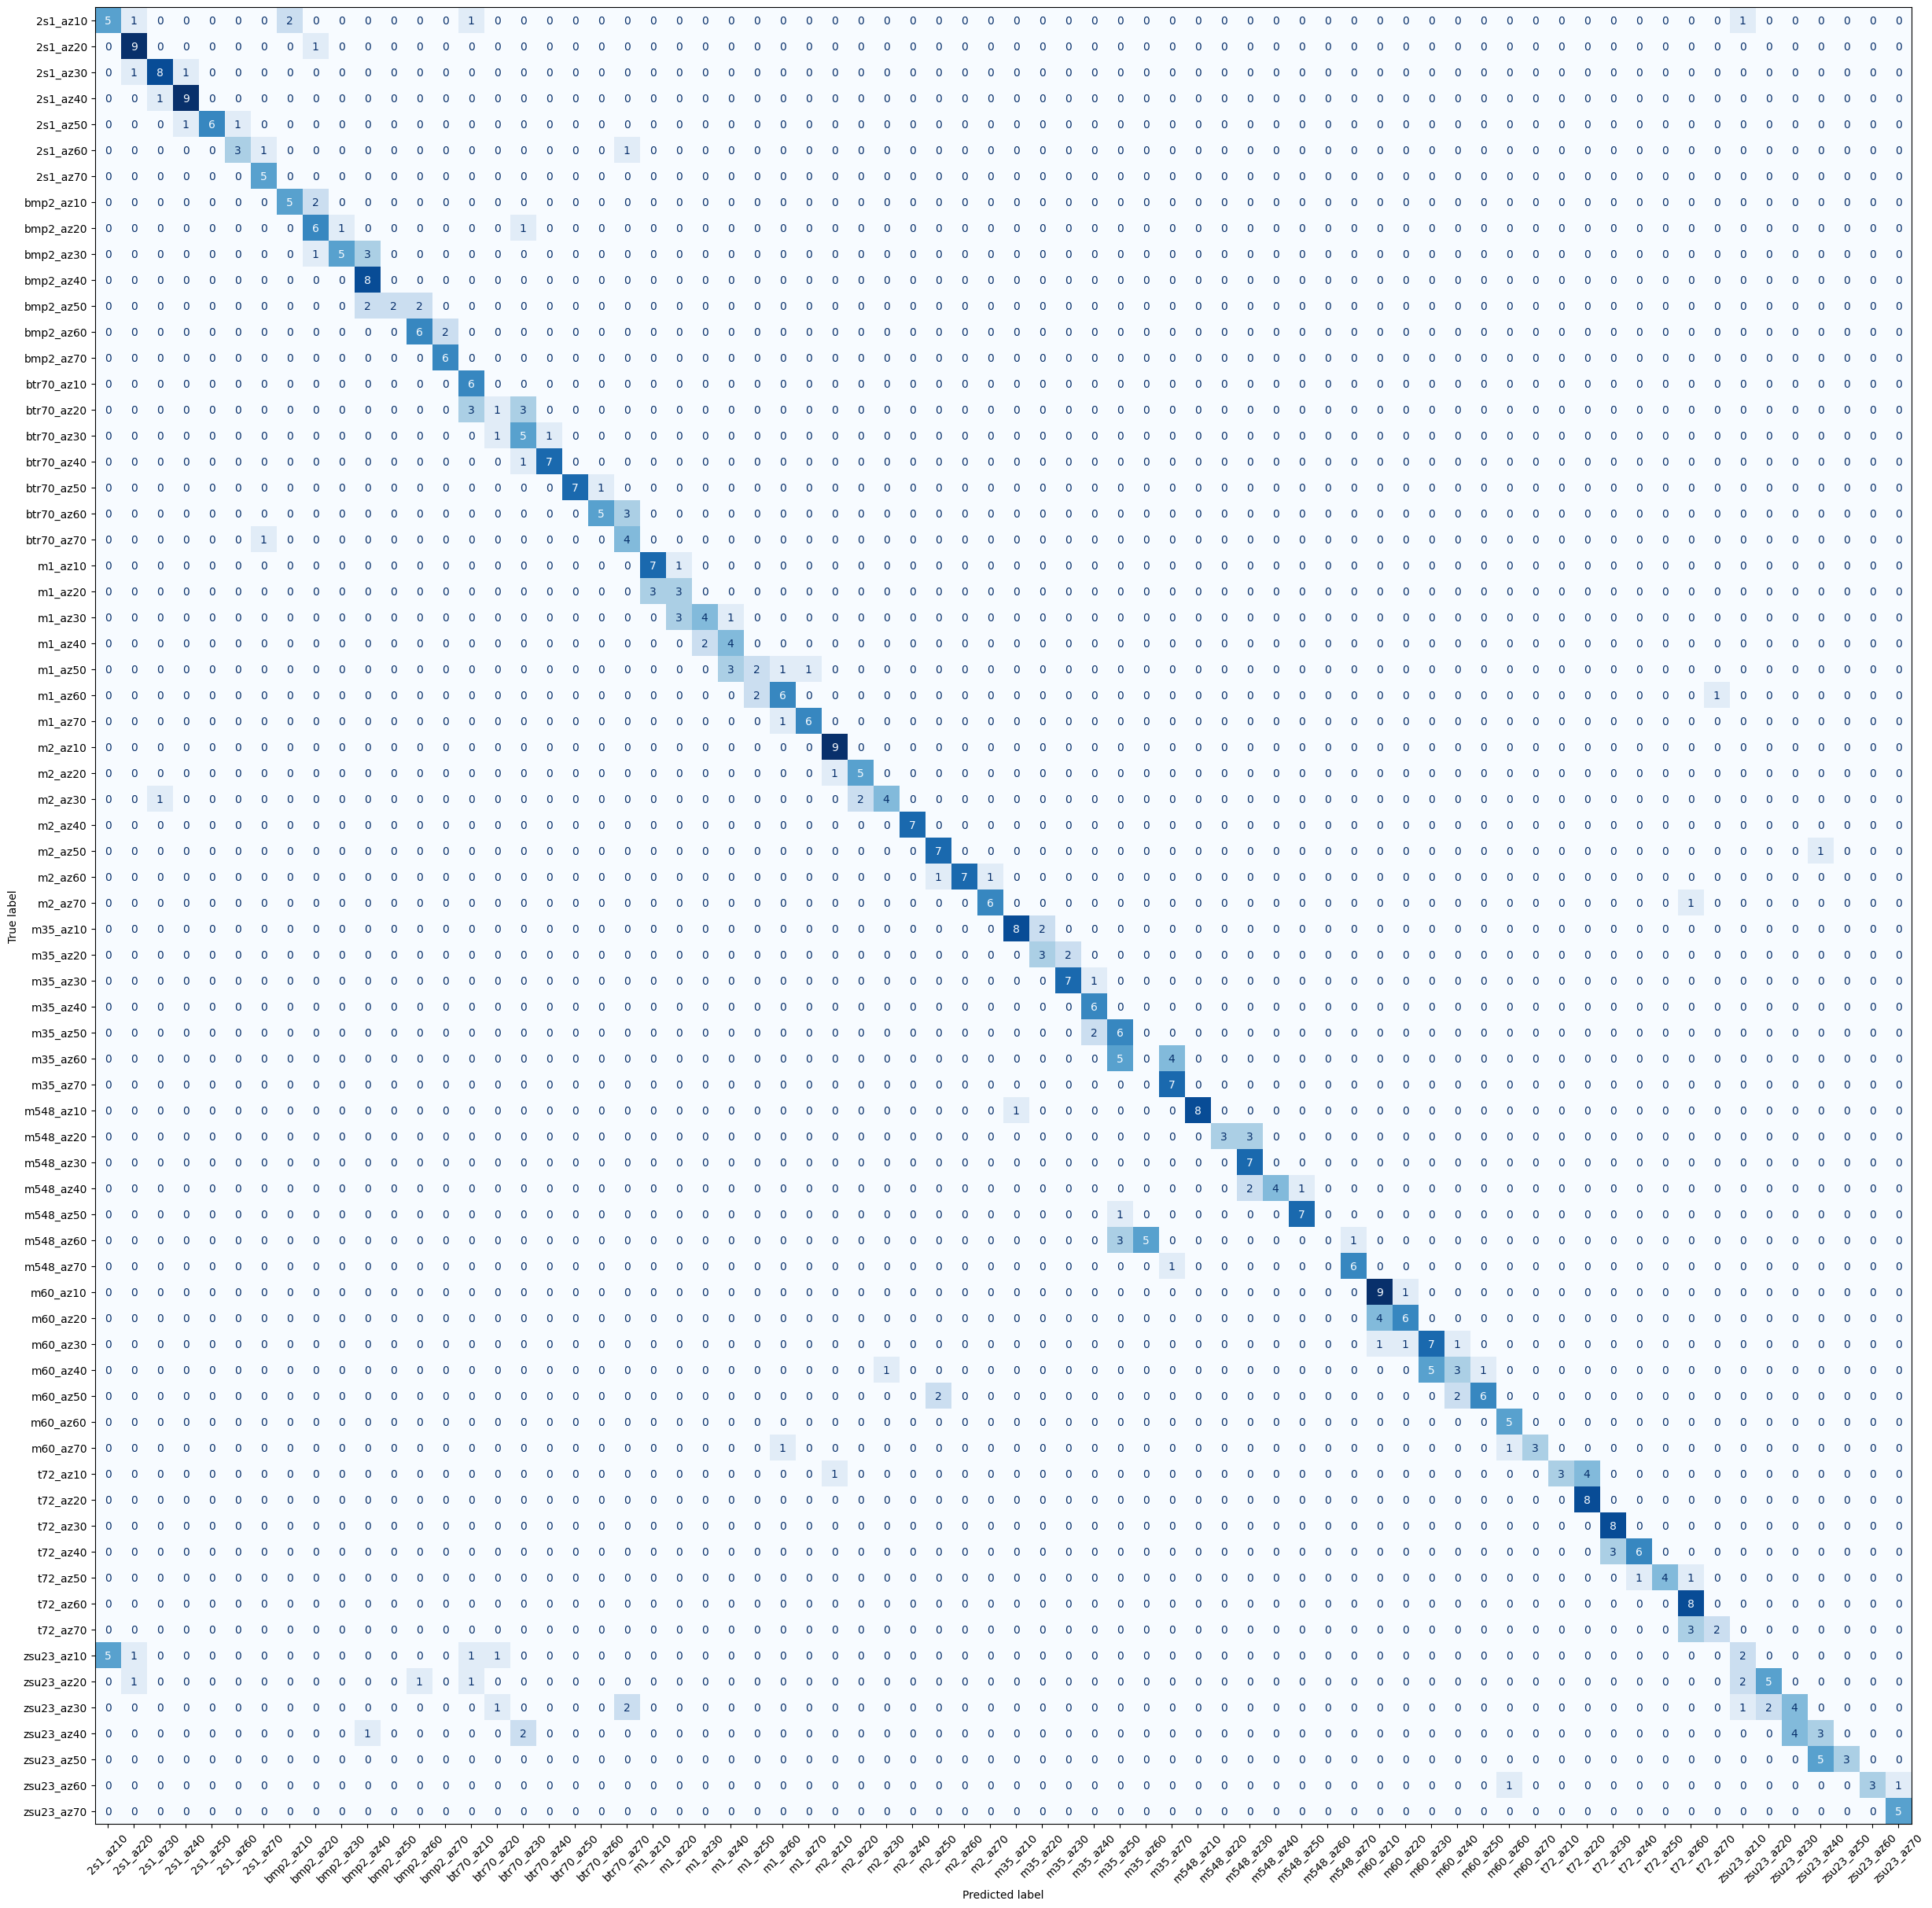

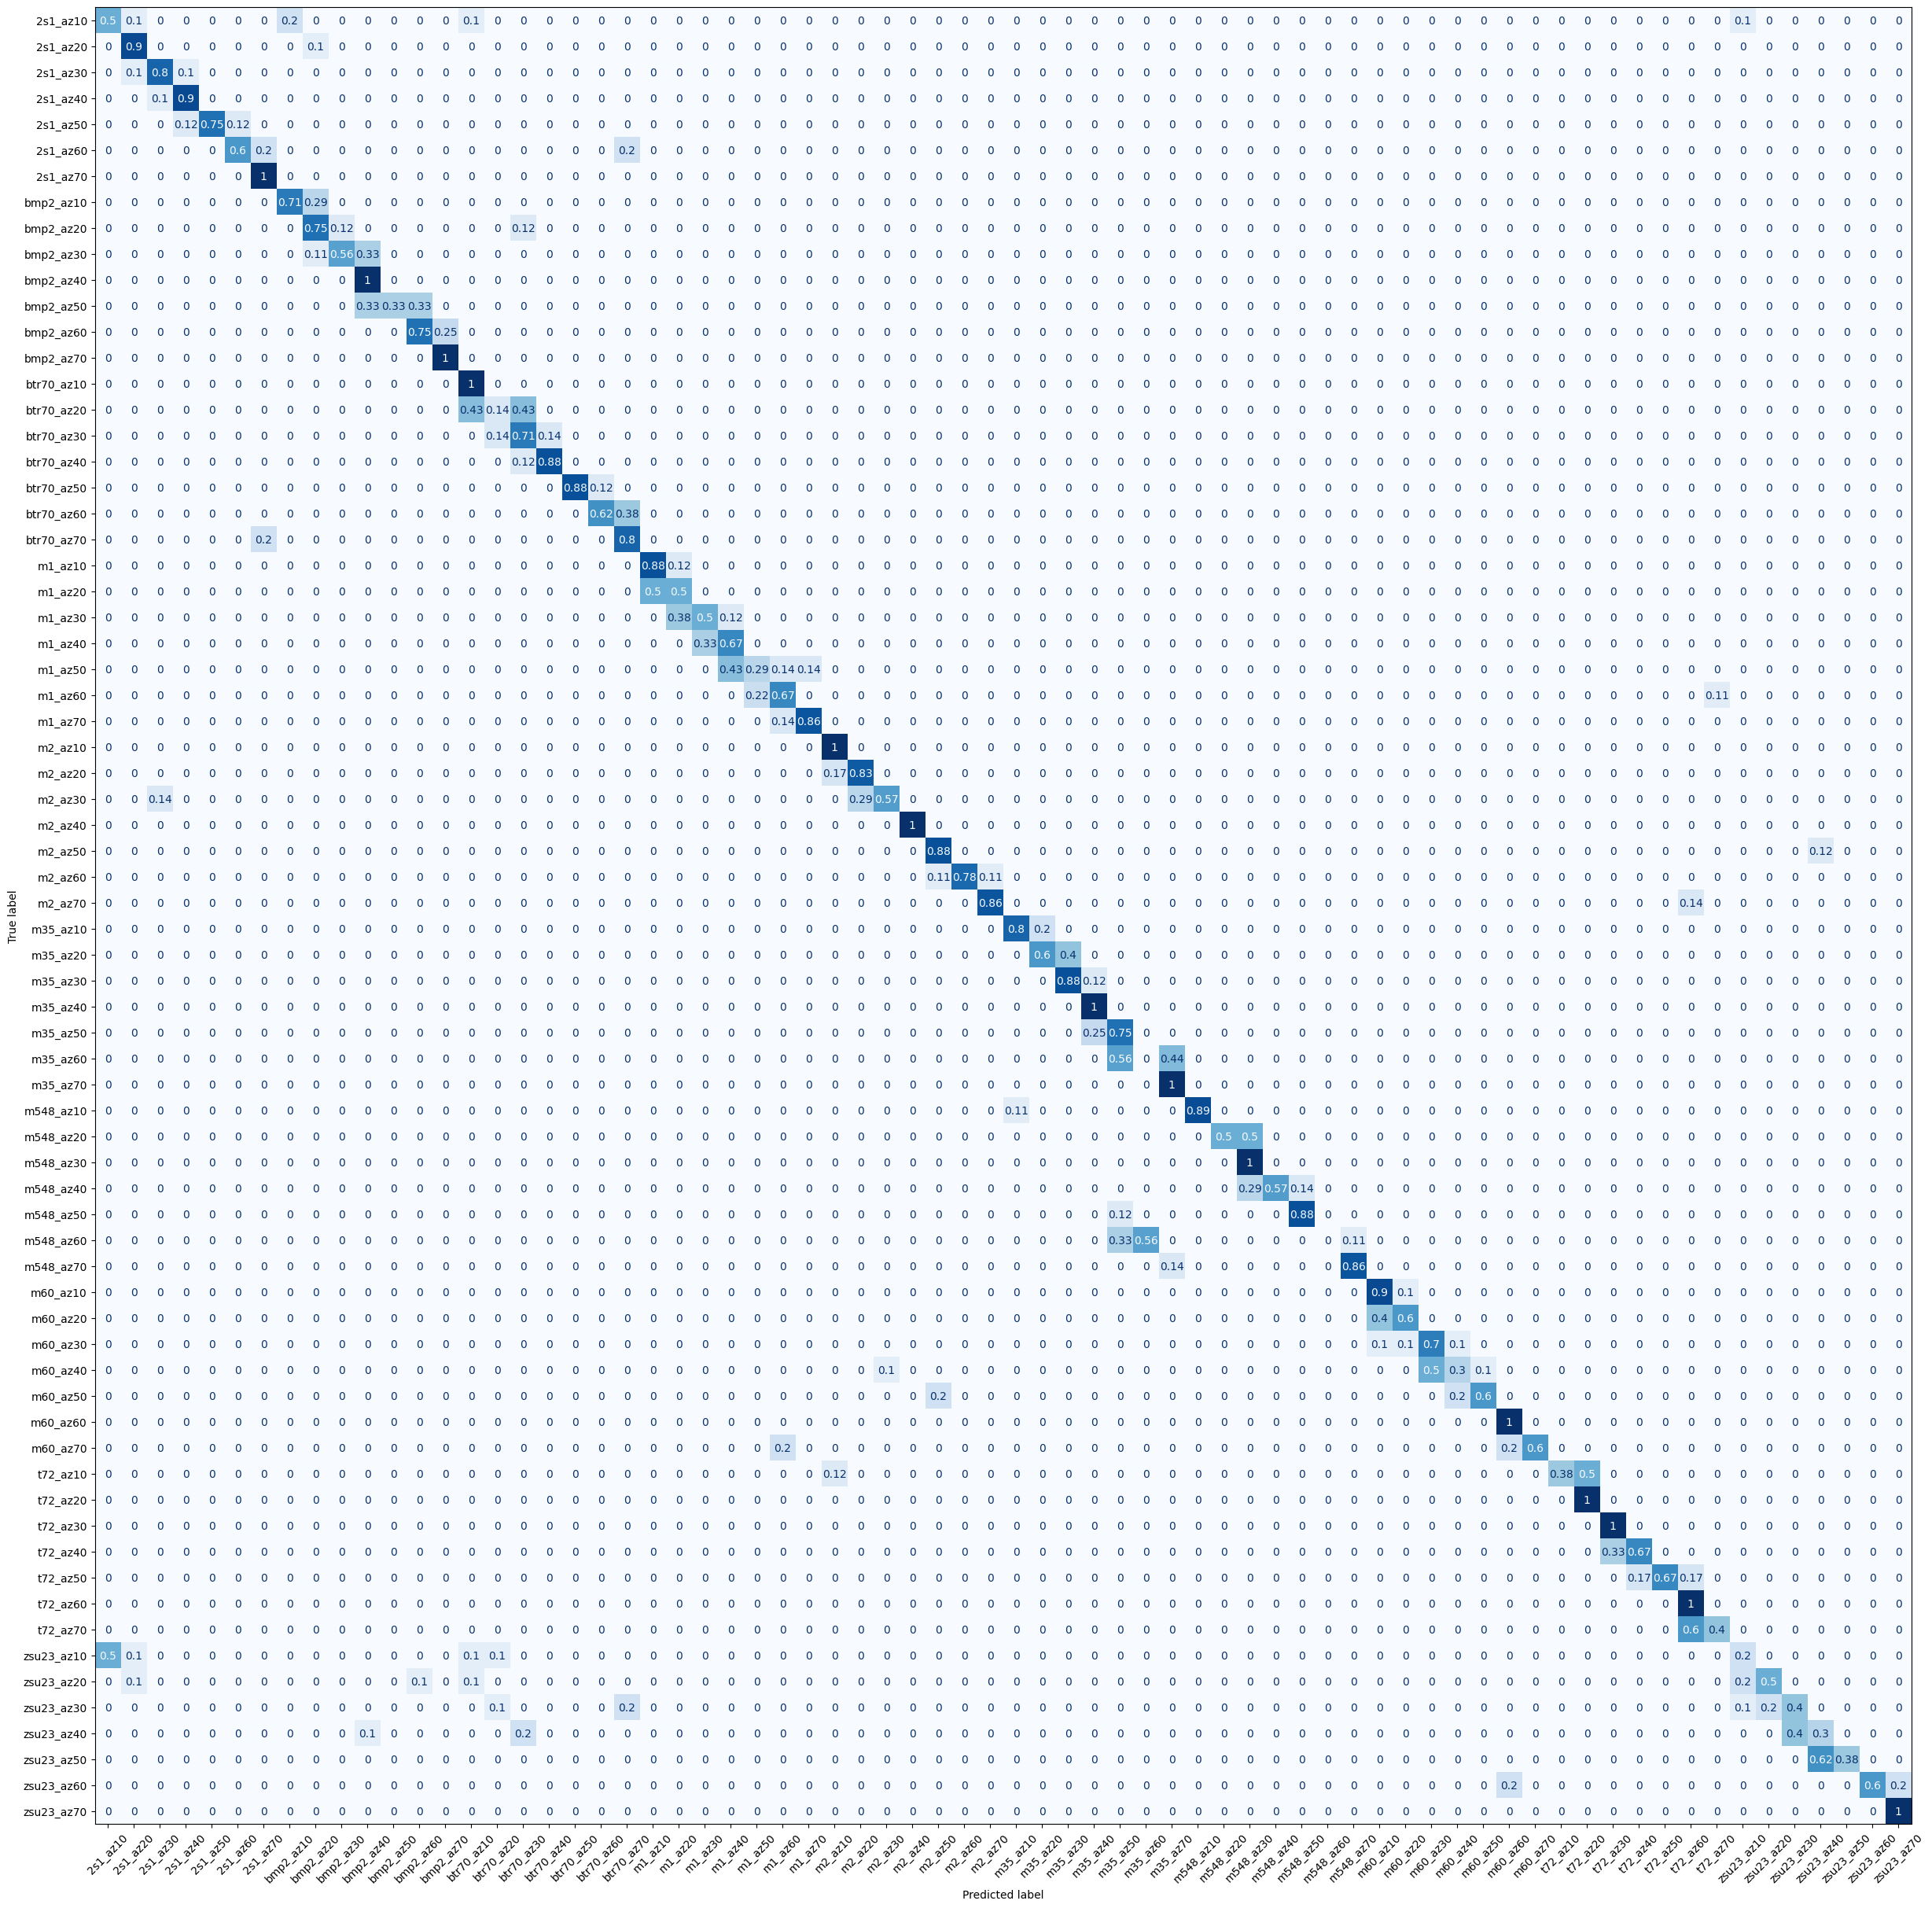

In [48]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
  
new_model = models.resnet18(weights = None) # dont load ImageNet Weights
new_model.fc = nn.Sequential(
    nn.Dropout(p = 0.4),
    nn.Linear(new_model.fc.in_features, len(train_ds.classes))
)

# Load your trained weights
new_model.load_state_dict(torch.load(
    os.path.join(workspace, f"weights/SSR/Extras/bins_10deg/SSR_w_noise/rn18_seed777_b16.pth"),
    map_location=device
))

new_model = new_model.to(device)
new_model.eval()

labels_lst, preds_lst = [], []

with torch.no_grad():
    for inputs, labels in DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=12, pin_memory=True, persistent_workers=True):
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = new_model(inputs)
        _, preds = torch.max(outputs, 1)

        labels_lst.append(labels)
        preds_lst.append(preds)

_labels_all = torch.cat(labels_lst).cpu().numpy()
_preds_all = torch.cat(preds_lst).cpu().numpy()

# confusion matrix
cm = confusion_matrix(_labels_all, _preds_all)
cm_cpu  = cp.asnumpy(cm)

disp = ConfusionMatrixDisplay(cm_cpu, display_labels = train_ds.classes)
fig, ax = plt.subplots(figsize=(30, 30))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.tick_params(axis='x', rotation=45)
plt.show()

cm_norm = confusion_matrix(_labels_all, _preds_all, normalize = "true")
cm_norm_cpu  = cp.asnumpy(cm_norm)
disp = ConfusionMatrixDisplay(cm_norm_cpu, display_labels = train_ds.classes)
fig, ax = plt.subplots(figsize=(30, 30))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.tick_params(axis='x', rotation=45)
plt.show()
plt.show()

In [49]:
seed_lst = [10, 42, 100, 123, 666, 777, 849, 1000, 1111, 1234]
# Evaluate all 10 trained models on test set
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
test_acc_lst = []
for i, seed in enumerate(seed_lst):
    print(f"Evaluating Run {i} with seed {seed}")
    new_model = models.resnet18(weights = None) # dont load ImageNet Weights
    # new_model.fc = nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
    new_model.fc = nn.Sequential(
        nn.Dropout(p = 0.4),
        nn.Linear(new_model.fc.in_features, len(train_ds.classes))
    )
    # Load your trained weights
    new_model.load_state_dict(torch.load(
        os.path.join(workspace, f"weights/SSR/Extras/bins_10deg/SSR_w_noise/rn18_seed{seed}_b16.pth"),
        map_location=device
    ))
    
    new_model = new_model.to(device)
    new_model.eval()

    labels_lst, preds_lst = [], []
    
    with torch.no_grad():
        for inputs, labels in DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=12, pin_memory=True, persistent_workers=True):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = new_model(inputs)
            _, preds = torch.max(outputs, 1)

            labels_lst.append(labels)
            preds_lst.append(preds)

    _labels_all = torch.cat(labels_lst).cpu().numpy()
    _preds_all = torch.cat(preds_lst).cpu().numpy()

    _old_class_labels = np.array([new_to_old_classes[_labels_all[i]] for i in range(len(_labels_all))])
    _old_class_preds = np.array([new_to_old_classes[_preds_all[i]] for i in range(len(_preds_all))])

    test_acc = (_old_class_labels == _old_class_preds).mean()
    print(f"Test Accuracy: {test_acc*100:.4f}")
    test_acc_lst.append(test_acc)

test_acc_arr = np.array(test_acc_lst)
print(f"Min: {test_acc_arr.min() * 100:.4f}")
print(f"Max: {test_acc_arr.max() * 100:.4f}")
print(f"Avg, Std: {test_acc_arr.mean() * 100:.4f}, {test_acc_arr.std() * 100:.4f}")

Evaluating Run 0 with seed 10
Test Accuracy: 90.1670
Evaluating Run 1 with seed 42
Test Accuracy: 92.9499
Evaluating Run 2 with seed 100
Test Accuracy: 91.8367
Evaluating Run 3 with seed 123
Test Accuracy: 87.5696
Evaluating Run 4 with seed 666
Test Accuracy: 89.4249
Evaluating Run 5 with seed 777
Test Accuracy: 91.4657
Evaluating Run 6 with seed 849
Test Accuracy: 87.9406
Evaluating Run 7 with seed 1000
Test Accuracy: 91.6512
Evaluating Run 8 with seed 1111
Test Accuracy: 87.7551
Evaluating Run 9 with seed 1234
Test Accuracy: 91.6512
Min: 87.5696
Max: 92.9499
Avg, Std: 90.2412, 1.8612


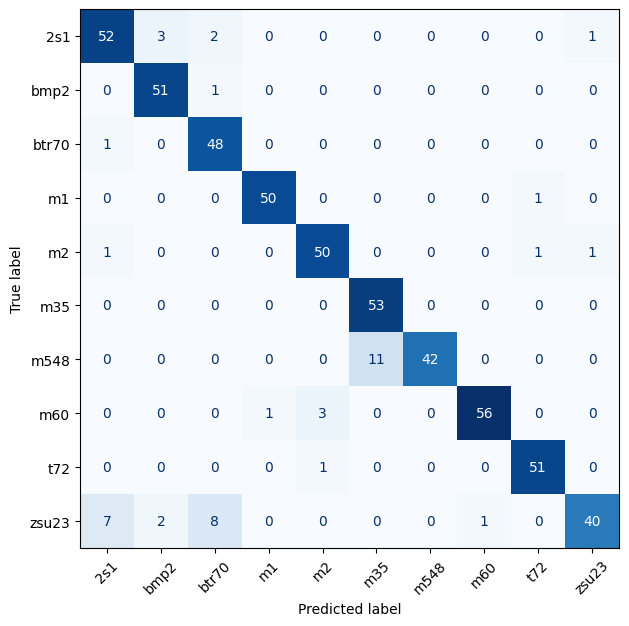

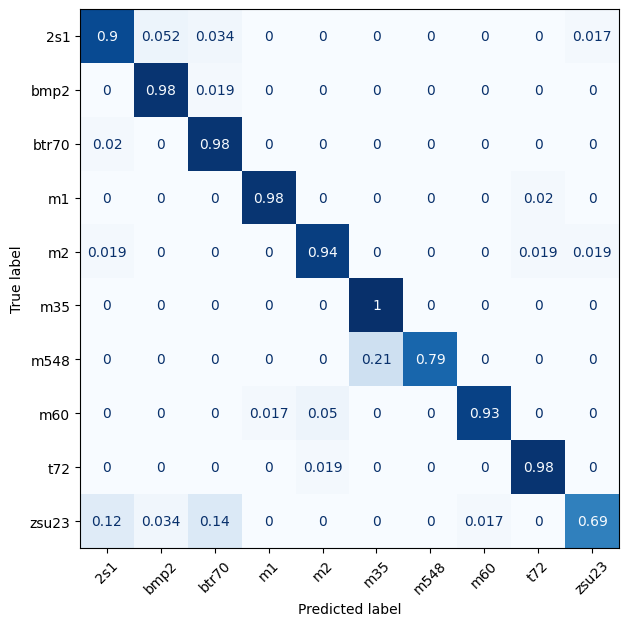

In [50]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
  
new_model = models.resnet18(weights = None) # dont load ImageNet Weights
new_model.fc = nn.Sequential(
    nn.Dropout(p = 0.4),
    nn.Linear(new_model.fc.in_features, len(train_ds.classes))
)

# Load your trained weights
new_model.load_state_dict(torch.load(
    os.path.join(workspace, f"weights/SSR/Extras/bins_10deg/SSR_w_noise/rn18_seed777_b16.pth"),
    map_location=device
))

new_model = new_model.to(device)
new_model.eval()

labels_lst, preds_lst = [], []

with torch.no_grad():
    for inputs, labels in DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=8, pin_memory=True, persistent_workers=True):
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = new_model(inputs)
        _, preds = torch.max(outputs, 1)

        labels_lst.append(labels)
        preds_lst.append(preds)

_labels_all = torch.cat(labels_lst).cpu().numpy()
_preds_all = torch.cat(preds_lst).cpu().numpy()

_old_class_labels = np.array([new_to_old_classes[_labels_all[i]] for i in range(len(_labels_all))])
_old_class_preds = np.array([new_to_old_classes[_preds_all[i]] for i in range(len(_preds_all))])

# confusion matrix
cm = confusion_matrix(_old_class_labels, _old_class_preds)
cm_cpu  = cp.asnumpy(cm)

disp = ConfusionMatrixDisplay(cm_cpu, display_labels = train_ds.dataset.classes)
fig, ax = plt.subplots(figsize=(7, 7))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.tick_params(axis='x', rotation=45)
plt.show()

cm_norm = confusion_matrix(_old_class_labels, _old_class_preds, normalize = "true")
cm_norm_cpu  = cp.asnumpy(cm_norm)
disp = ConfusionMatrixDisplay(cm_norm_cpu, display_labels = train_ds.dataset.classes)
fig, ax = plt.subplots(figsize=(7, 7))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.tick_params(axis='x', rotation=45)
plt.show()
plt.show()

In [67]:
def make_vehicle_bin_colors(n_vehicles, n_bins_per_vehicle, start_lightness=0.3):
    """
    For each vehicle, interpolate from a light tint to the tab10 base colour.
    Returns a flat list of (R,G,B) colours indexed by new_label (bin index).
    """
    tab10 = plt.colormaps["tab10"]
    bin_colors = []
    
    for v in range(n_vehicles):
        base = np.array(tab10(v)[:3])  # RGB of tab10 colour for vehicle v
        white = np.ones(3)
        # linspace from near-white to full colour, n_bins steps
        # start at start_lightness (not pure white) so first bin is still visible
        alphas = np.linspace(start_lightness, 1.0, n_bins_per_vehicle)
        for a in alphas:
            color = (1 - a) * white + a * base
            bin_colors.append(tuple(color))
    
    return bin_colors

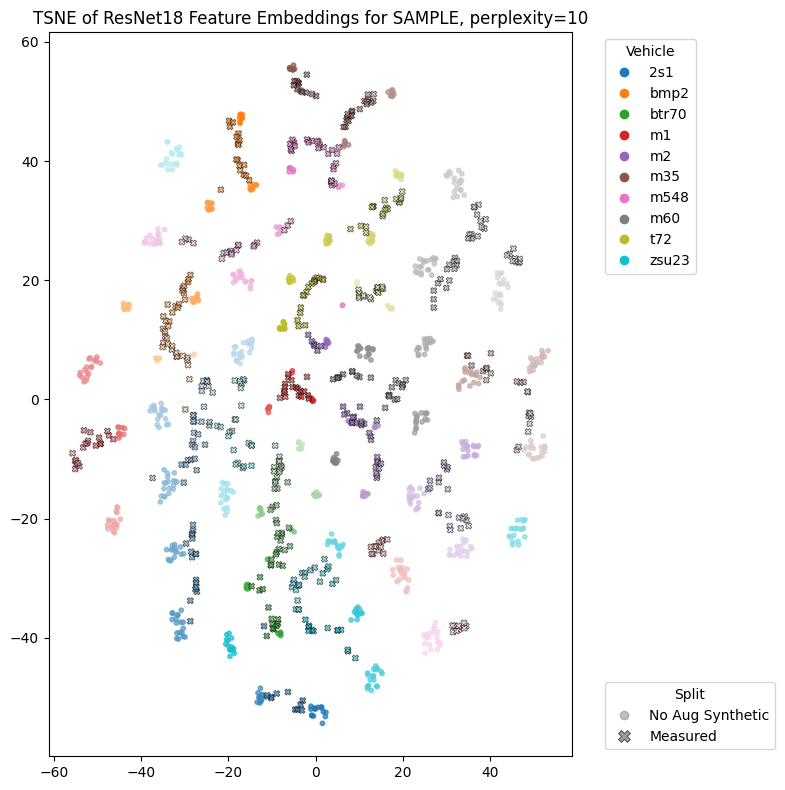

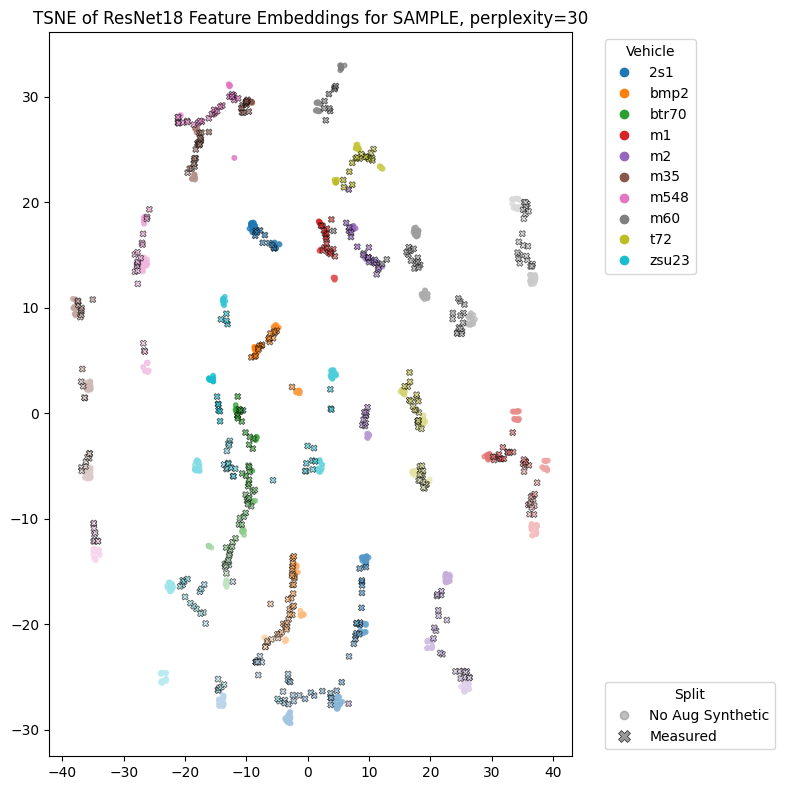

[2026-06-19 19:44:21.551] [CUML] [warning] # of Nearest Neighbors should be at least 3 * perplexity. Your results might be a bit strange...


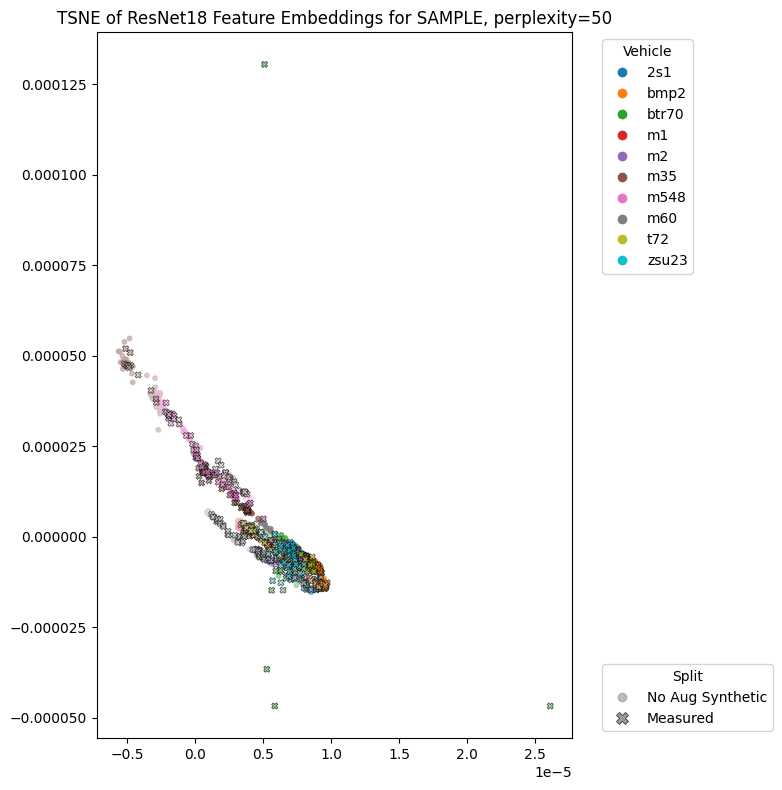

[2026-06-19 19:44:24.314] [CUML] [warning] Perplexity should be within ranges (5, 50). Your results might be a bit strange...
[2026-06-19 19:44:24.314] [CUML] [warning] # of Nearest Neighbors should be at least 3 * perplexity. Your results might be a bit strange...


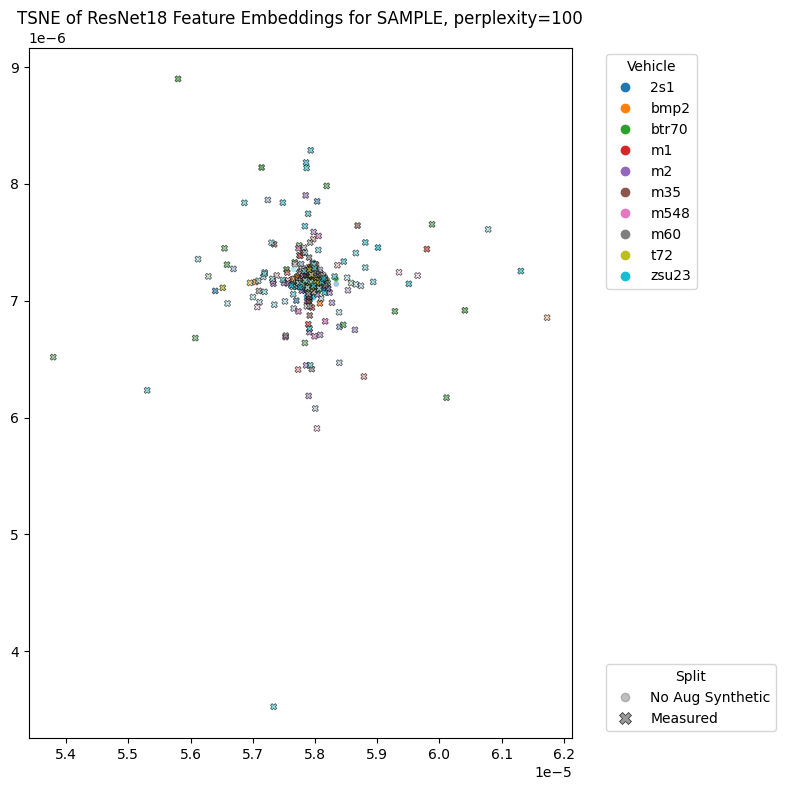

In [82]:
meas_ds_17 = filter_by_elev(meas_ds, {17})
s, b, total_bins, new_classes, new_to_old_classes = build_azimuth_bin_map(meas_ds_17, bin_width=10)
test_plot_ds =  AzimuthBinnedDataset(meas_ds_17, s, new_classes)

no_aug_synth_ds_14_15_16 = filter_by_elev(no_aug_synth_ds, {14, 15, 16})
s, b, total_bins, new_classes_train, new_to_old_classes_train = build_azimuth_bin_map(no_aug_synth_ds_14_15_16, bin_width=10)
train_plot_ds =  AzimuthBinnedDataset(no_aug_synth_ds_14_15_16, s, new_classes_train)

combined_ds = ConcatDataset([train_plot_ds, test_plot_ds])
combined_loader = DataLoader(combined_ds, batch_size=32, shuffle=False, num_workers=8, pin_memory=True, persistent_workers=True)


for num in [10, 30, 50, 100]:
    
    set_seed(777)
    
    device = torch.device("cuda:0")
    new_model = models.resnet18(weights = None) # dont load ImageNet Weights
    # new_model.fc = nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
    new_model.fc = nn.Sequential(
            nn.Dropout(p = 0.4),
            nn.Linear(new_model.fc.in_features, len(train_plot_ds.classes))
        )
    # Load your trained weights
    new_model.load_state_dict(torch.load(
        os.path.join(workspace, f"weights/SSR/Extras/bins_10deg/SSR_w_noise/rn18_seed777_b16.pth"),
        map_location=device
    ))

    new_model = new_model.to(device)
    new_model.eval()

    feature_extractor = nn.Sequential(*list(new_model.children())[:-1])
    feature_extractor = feature_extractor.to(device)
    feature_extractor.eval()

    features, labels_list = [], []

    with torch.no_grad():
        for inputs, targets in combined_loader:
            inputs = inputs.to(device)
            feats = feature_extractor(inputs)
            feats = feats.view(feats.size(0), -1)
            features.append(feats.cpu())
            labels_list.append(targets)

    features = torch.cat(features).numpy()
    labels_list = torch.cat(labels_list).numpy()

    tsne = TSNE(
        n_components=2,
        perplexity=num,
        learning_rate_method="adaptive",
        metric = "cosine"
    )

    features_2d = tsne.fit_transform(features)

    n_vehicles = len(train_plot_ds.dataset.classes)
    n_bins_per_vehicle = total_bins // n_vehicles 

    bin_colors = make_vehicle_bin_colors(n_vehicles, n_bins_per_vehicle)

    def labels_to_colors(label_array, bin_colors):
        return [bin_colors[l] for l in label_array]

    train_colors = labels_to_colors(labels_list[:len(train_plot_ds)], bin_colors)
    test_colors  = labels_to_colors(labels_list[len(train_plot_ds):], bin_colors)

    fig = plt.figure(figsize=(8, 8))
    scatter = plt.scatter(
        features_2d[:len(train_plot_ds), 0],
        features_2d[:len(train_plot_ds), 1],
        c=train_colors,
        s=10,
        alpha=0.7,
        marker = "o"
    )

    plt.scatter(
        features_2d[len(train_plot_ds):, 0],
        features_2d[len(train_plot_ds):, 1],
        c=test_colors,
        s=20,
        alpha=0.7,
        linewidths=0.5,
        marker = "X",
        edgecolors="k"
    )

    tab10 = plt.colormaps["tab10"]
    vehicle_handles = [
        Line2D([0], [0], marker="o", color=tab10(v), linestyle="None",
            markersize=6, label=train_plot_ds.dataset.classes[v])
        for v in range(n_vehicles)
    ]
    class_legend = plt.legend(handles=vehicle_handles, title="Vehicle",
                            bbox_to_anchor=(1.05, 1), loc="upper left")
    fig.add_artist(class_legend)

    marker_handles = [
        Line2D([0], [0], marker="o", color="grey", linestyle="None", markersize=6, alpha=0.5, label="No Aug Synthetic"),
        Line2D([0], [0], marker="X", color="grey", linestyle="None", markersize=8, alpha=0.8, markeredgecolor="k", markeredgewidth=0.5, label="Measured"),
    ]
    plt.legend(handles=marker_handles, title="Split", bbox_to_anchor=(1.05, 0), loc="lower left")

    plt.title(f"TSNE of ResNet18 Feature Embeddings for SAMPLE, perplexity={num}")
    plt.tight_layout()
    plt.show()

[2026-06-19 19:44:58.463] [CUML] [info] Building knn graph using brute force (configured from build_algo='auto')


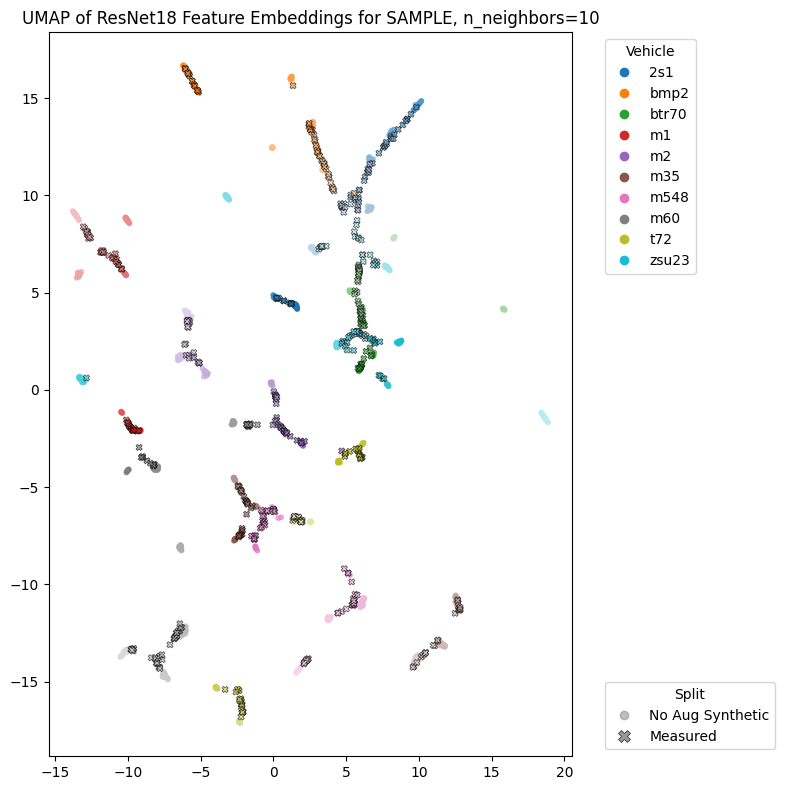

[2026-06-19 19:45:01.001] [CUML] [info] Building knn graph using brute force (configured from build_algo='auto')


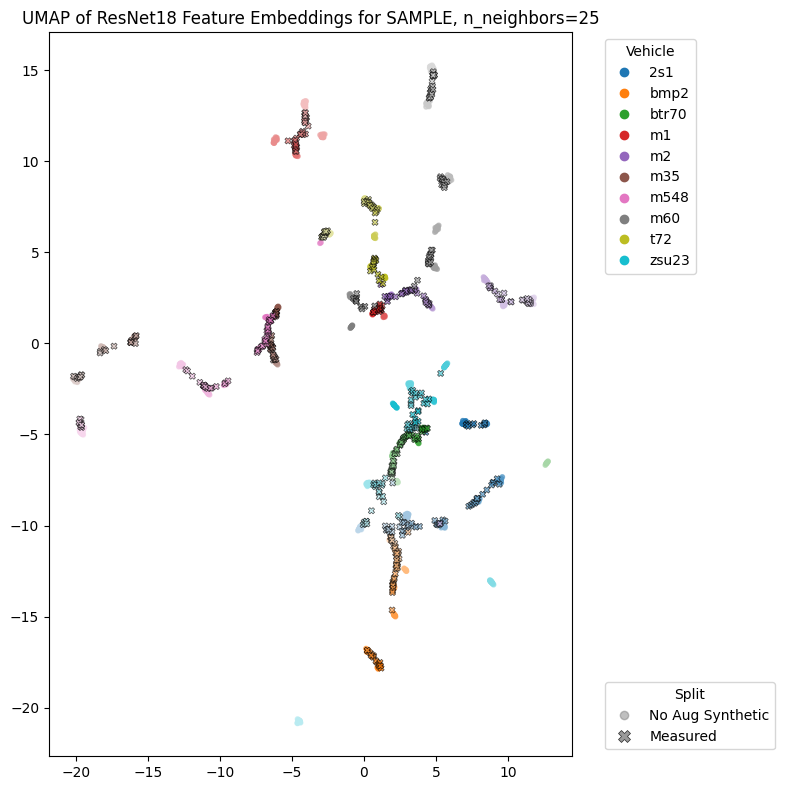

[2026-06-19 19:45:03.924] [CUML] [info] Building knn graph using brute force (configured from build_algo='auto')


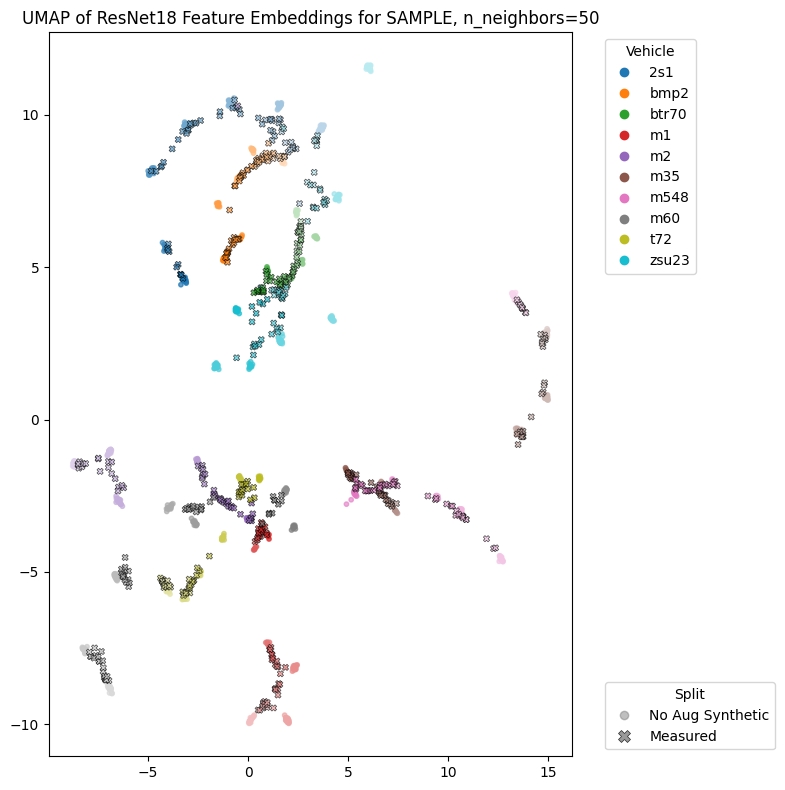

[2026-06-19 19:45:06.210] [CUML] [info] Building knn graph using brute force (configured from build_algo='auto')


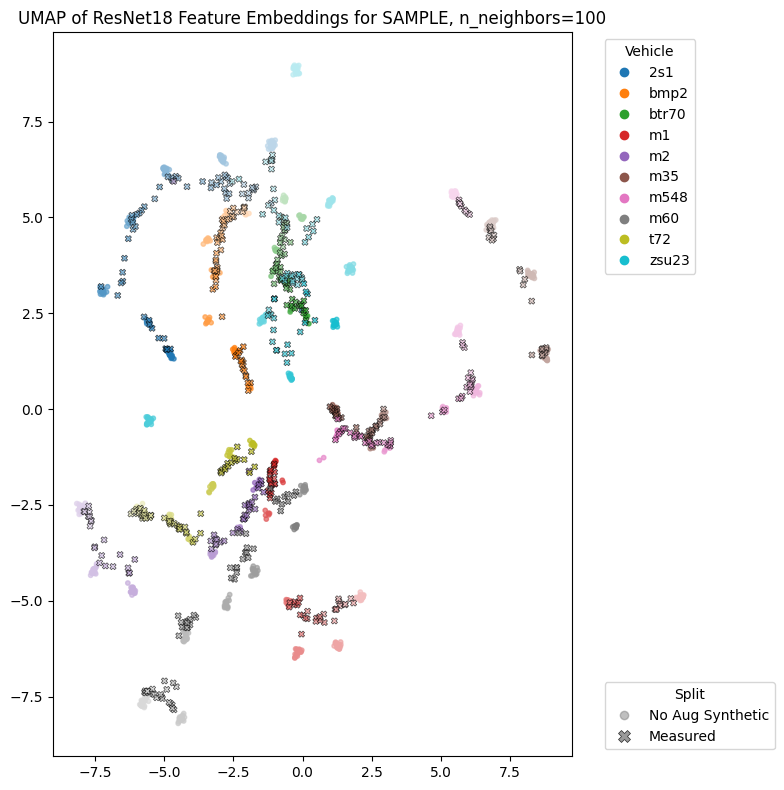

In [83]:
meas_ds_17 = filter_by_elev(meas_ds, {17})
s, b, total_bins, new_classes, new_to_old_classes = build_azimuth_bin_map(meas_ds_17, bin_width=10)
test_plot_ds =  AzimuthBinnedDataset(meas_ds_17, s, new_classes)

no_aug_synth_ds_14_15_16 = filter_by_elev(no_aug_synth_ds, {14, 15, 16})
s, b, total_bins, new_classes_train, new_to_old_classes_train = build_azimuth_bin_map(no_aug_synth_ds_14_15_16, bin_width=10)
train_plot_ds =  AzimuthBinnedDataset(no_aug_synth_ds_14_15_16, s, new_classes_train)

combined_ds = ConcatDataset([train_plot_ds, test_plot_ds])
combined_loader = DataLoader(combined_ds, batch_size=32, shuffle=False, num_workers=8, pin_memory=True, persistent_workers=True)


for num in [10, 25, 50, 100]:

    set_seed(777)

    device = torch.device("cuda:0")
    new_model = models.resnet18(weights = None) # dont load ImageNet Weights
    # new_model.fc = nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
    new_model.fc = nn.Sequential(
            nn.Dropout(p = 0.4),
            nn.Linear(new_model.fc.in_features, len(train_plot_ds.classes))
        )
    # Load your trained weights
    new_model.load_state_dict(torch.load(
        os.path.join(workspace, f"weights/SSR/Extras/bins_10deg/SSR_w_noise/rn18_seed777_b16.pth"),
        map_location=device
    ))

    new_model = new_model.to(device)
    new_model.eval()

    feature_extractor = nn.Sequential(*list(new_model.children())[:-1])
    feature_extractor = feature_extractor.to(device)
    feature_extractor.eval()

    features, labels_list = [], []

    with torch.no_grad():
        for inputs, targets in combined_loader:
            inputs = inputs.to(device)
            feats = feature_extractor(inputs)
            feats = feats.view(feats.size(0), -1)
            features.append(feats.cpu())
            labels_list.append(targets)

    features = torch.cat(features).numpy()
    labels_list = torch.cat(labels_list).numpy()

    reducer = UMAP(
        n_neighbors=num,
        min_dist=0.25,
        n_components=2,
        metric = "cosine"
    )

    features_2d_umap = reducer.fit_transform(features)

    n_vehicles = len(train_plot_ds.dataset.classes)
    n_bins_per_vehicle = total_bins // n_vehicles 

    bin_colors = make_vehicle_bin_colors(n_vehicles, n_bins_per_vehicle)

    def labels_to_colors(label_array, bin_colors):
        return [bin_colors[l] for l in label_array]

    train_colors = labels_to_colors(labels_list[:len(train_plot_ds)], bin_colors)
    test_colors  = labels_to_colors(labels_list[len(train_plot_ds):], bin_colors)

    fig = plt.figure(figsize=(8, 8))
    scatter = plt.scatter(
        features_2d_umap[:len(train_plot_ds), 0],
        features_2d_umap[:len(train_plot_ds), 1],
        c=train_colors,
        s=10,
        alpha=0.7,
        marker = "o"
    )

    plt.scatter(
        features_2d_umap[len(train_plot_ds):, 0],
        features_2d_umap[len(train_plot_ds):, 1],
        c=test_colors,
        s=20,
        alpha=0.7,
        linewidths=0.5,
        marker = "X",
        edgecolors="k"
    )

    tab10 = plt.colormaps["tab10"]
    vehicle_handles = [
        Line2D([0], [0], marker="o", color=tab10(v), linestyle="None",
            markersize=6, label=train_plot_ds.dataset.classes[v])
        for v in range(n_vehicles)
    ]
    class_legend = plt.legend(handles=vehicle_handles, title="Vehicle",
                            bbox_to_anchor=(1.05, 1), loc="upper left")
    fig.add_artist(class_legend)

    marker_handles = [
        Line2D([0], [0], marker="o", color="grey", linestyle="None", markersize=6, alpha=0.5, label="No Aug Synthetic"),
        Line2D([0], [0], marker="X", color="grey", linestyle="None", markersize=8, alpha=0.8, markeredgecolor="k", markeredgewidth=0.5, label="Measured"),
    ]
    plt.legend(handles=marker_handles, title="Split", bbox_to_anchor=(1.05, 0), loc="lower left")

    plt.title(f"UMAP of ResNet18 Feature Embeddings for SAMPLE, n_neighbors={num}")
    plt.tight_layout()
    plt.show()

In [73]:
SSR_synth_ds_14_15_16 = filter_by_elev(SSR_synth_ds, {14, 15, 16})
s, b, total_bins, new_classes, new_to_old_classes = build_azimuth_bin_map(SSR_synth_ds_14_15_16, bin_width=10)
new_SSR_synth_ds_14_15_16 = AzimuthBinnedDataset(SSR_synth_ds_14_15_16, s, new_classes)

no_aug_synth_ds_14_15_16 = filter_by_elev(no_aug_synth_ds, {14, 15, 16})
s, b, total_bins, new_classes_train, new_to_old_classes_train = build_azimuth_bin_map(no_aug_synth_ds_14_15_16, bin_width=10)
new_no_aug_synth_ds_14_15_16 = AzimuthBinnedDataset(no_aug_synth_ds_14_15_16, s, new_classes_train)

meas_ds_17 = filter_by_elev(meas_ds, {17})
s, b, total_bins, new_classes_test, new_to_old_classes_test = build_azimuth_bin_map(meas_ds_17, bin_width=10)
new_meas_ds_17 = AzimuthBinnedDataset(meas_ds_17, s, new_classes_test)


seed = 777
set_seed(seed)

device = torch.device("cuda:0")
torch.cuda.set_device(device)

# ── Model ────────────────────────────────────────────────────────────────────
new_model = models.resnet18(weights=None)
new_model.fc = nn.Sequential(
    nn.Dropout(p=0.4),
    nn.Linear(new_model.fc.in_features, len(new_SSR_synth_ds_14_15_16.classes))
)
new_model.load_state_dict(torch.load(
    os.path.join(workspace, f"weights/SSR/Extras/bins_10deg/SSR_w_noise/rn18_seed777_b16.pth"),
    map_location=device
))
new_model = new_model.to(device).eval()

feature_extractor = nn.Sequential(*list(new_model.children())[:-1]).to(device).eval()

# ── SSR aug synth — 200 epoch accumulation ───────────────────────────────────
SSR_synth_loader = DataLoader(
    new_SSR_synth_ds_14_15_16, batch_size=32,
    shuffle=False, num_workers=8,
    pin_memory=True, persistent_workers=True, prefetch_factor=4,
    worker_init_fn=worker_init_fn,
    generator=torch.Generator().manual_seed(seed)
)

n_synth = len(new_SSR_synth_ds_14_15_16)
SSR_synth_feats_gpu  = torch.zeros(200 * n_synth, 512, device=device)
SSR_synth_labels_gpu = torch.zeros(200 * n_synth, dtype=torch.long, device=device)

idx = 0
for epoch in tqdm(range(200), leave=False, position=0, desc="Epochs"):
    with torch.no_grad():
        for inputs, targets in tqdm(SSR_synth_loader, leave=False, position=1, desc="Batches"):
            inputs = inputs.to(device)
            feats = feature_extractor(inputs).view(inputs.size(0), -1)
            bs = feats.size(0)
            SSR_synth_feats_gpu[idx:idx+bs]  = feats
            SSR_synth_labels_gpu[idx:idx+bs] = targets.to(device)
            idx += bs

torch.cuda.synchronize()  # Ensure all GPU operations are complete before moving data to CPU

SSR_synth_feats  = SSR_synth_feats_gpu.cpu().numpy()
SSR_synth_labels = SSR_synth_labels_gpu.cpu().numpy()

# ── no aug synth — single pass ───────────────────────────────────────────────────────
synth_loader = DataLoader(
    new_no_aug_synth_ds_14_15_16, batch_size=32,
    shuffle=False, num_workers=8,
    pin_memory=True, persistent_workers=True, prefetch_factor=4,
    worker_init_fn=worker_init_fn,
    generator=torch.Generator().manual_seed(seed)
)

n_no_aug_synth = len(new_no_aug_synth_ds_14_15_16)
synth_feats_gpu  = torch.zeros(n_no_aug_synth, 512, device=device)
synth_labels_gpu = torch.zeros(n_no_aug_synth, dtype=torch.long, device=device)

idx = 0
with torch.no_grad():
    for inputs, targets in tqdm(synth_loader, leave=False, position=1, desc="Batches"):
        inputs = inputs.to(device)
        feats = feature_extractor(inputs).view(inputs.size(0), -1)
        bs = feats.size(0)
        synth_feats_gpu[idx:idx+bs]  = feats
        synth_labels_gpu[idx:idx+bs] = targets.to(device)
        idx += bs

torch.cuda.synchronize()  # Ensure all GPU operations are complete before moving data to CPU

synth_feats  = synth_feats_gpu.cpu().numpy()
synth_labels = synth_labels_gpu.cpu().numpy()

# ── meas — single pass ───────────────────────────────────────────────────────
meas_loader = DataLoader(
    new_meas_ds_17, batch_size=32,
    shuffle=False, num_workers=8,
    pin_memory=True, persistent_workers=True, prefetch_factor=4,
    worker_init_fn=worker_init_fn,
    generator=torch.Generator().manual_seed(seed)
)

n_meas = len(new_meas_ds_17)
meas_feats_gpu  = torch.zeros(n_meas, 512, device=device)
meas_labels_gpu = torch.zeros(n_meas, dtype=torch.long, device=device)

idx = 0
with torch.no_grad():
    for inputs, targets in tqdm(meas_loader, leave=False, desc="Meas"):
        inputs = inputs.to(device)
        feats = feature_extractor(inputs).view(inputs.size(0), -1)
        bs = feats.size(0)
        meas_feats_gpu[idx:idx+bs]  = feats
        meas_labels_gpu[idx:idx+bs] = targets.to(device)
        idx += bs

torch.cuda.synchronize()  # Ensure all GPU operations are complete before moving data to CPU

meas_feats  = meas_feats_gpu.cpu().numpy()
meas_labels = meas_labels_gpu.cpu().numpy()

In [86]:
len(train_colors)

1345

[2026-06-19 19:53:08.459] [CUML] [info] Building knn graph using nn descent (configured from build_algo='auto')


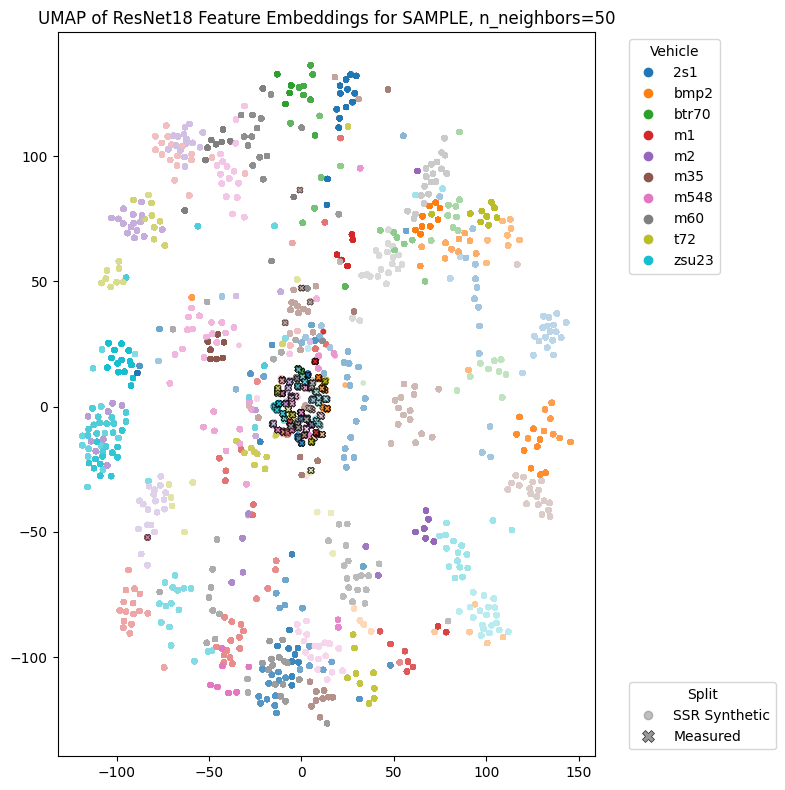

[2026-06-19 19:53:12.540] [CUML] [info] Building knn graph using nn descent (configured from build_algo='auto')
[2026-06-19 19:53:12.541] [CUML] [warning] to use nn descent as the build algo, nnd_graph_degree should be larger than or equal to n_neigbors. setting nnd_graph_degree to n_neighbors.


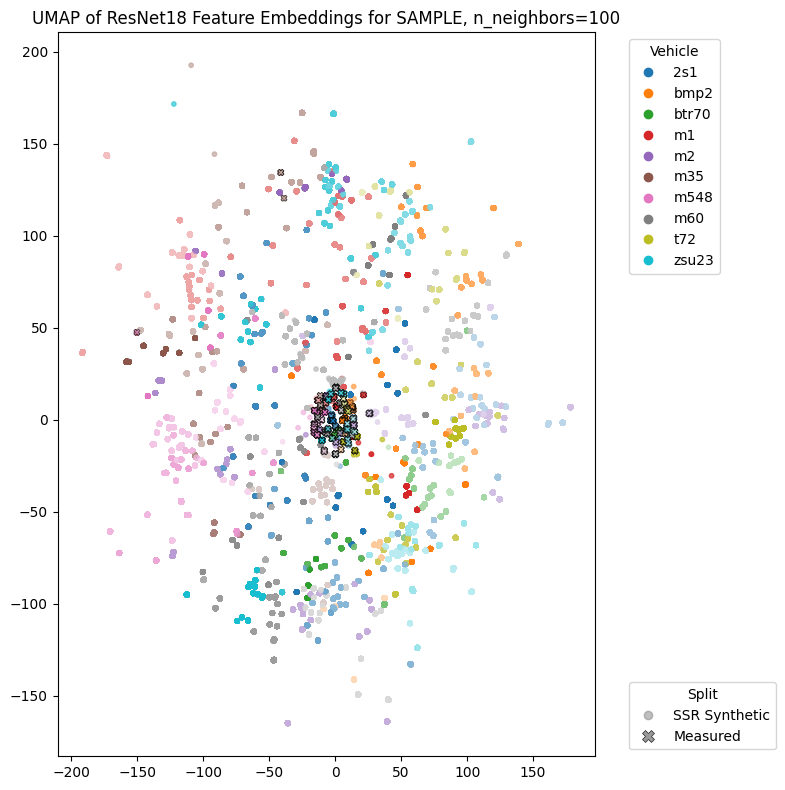

[2026-06-19 19:53:17.664] [CUML] [info] Building knn graph using nn descent (configured from build_algo='auto')
[2026-06-19 19:53:17.665] [CUML] [warning] to use nn descent as the build algo, nnd_graph_degree should be larger than or equal to n_neigbors. setting nnd_graph_degree to n_neighbors.
[2026-06-19 19:53:17.665] [CUML] [warning] to use nn descent as the build algo, nnd_intermediate_graph_degree should be larger than or equal to nnd_graph_degree. setting nnd_intermediate_graph_degree to nnd_graph_degree


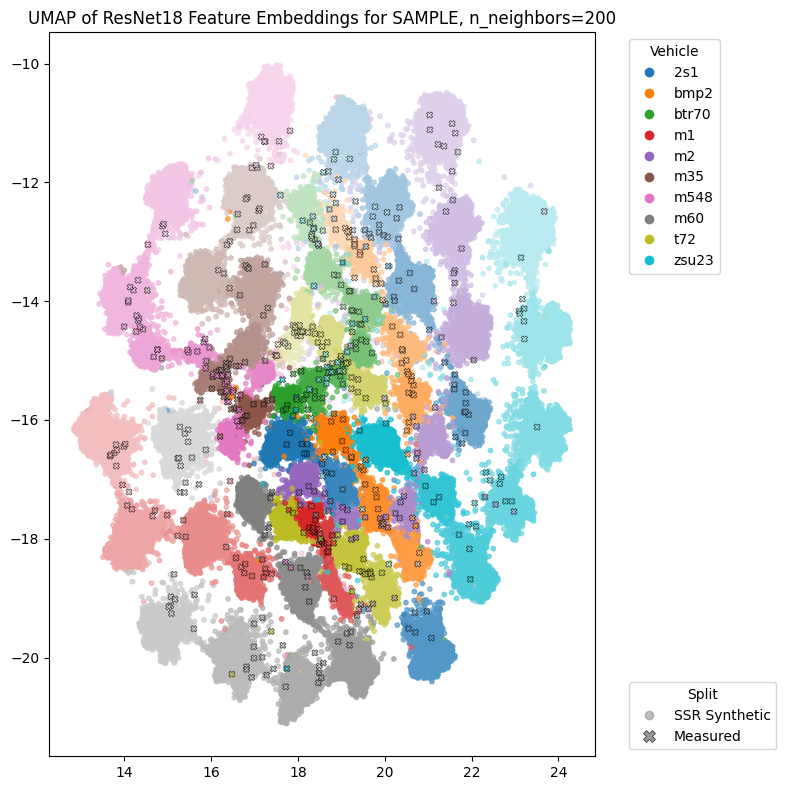

[2026-06-19 19:53:25.286] [CUML] [info] Building knn graph using nn descent (configured from build_algo='auto')
[2026-06-19 19:53:25.288] [CUML] [warning] to use nn descent as the build algo, nnd_graph_degree should be larger than or equal to n_neigbors. setting nnd_graph_degree to n_neighbors.
[2026-06-19 19:53:25.288] [CUML] [warning] to use nn descent as the build algo, nnd_intermediate_graph_degree should be larger than or equal to nnd_graph_degree. setting nnd_intermediate_graph_degree to nnd_graph_degree


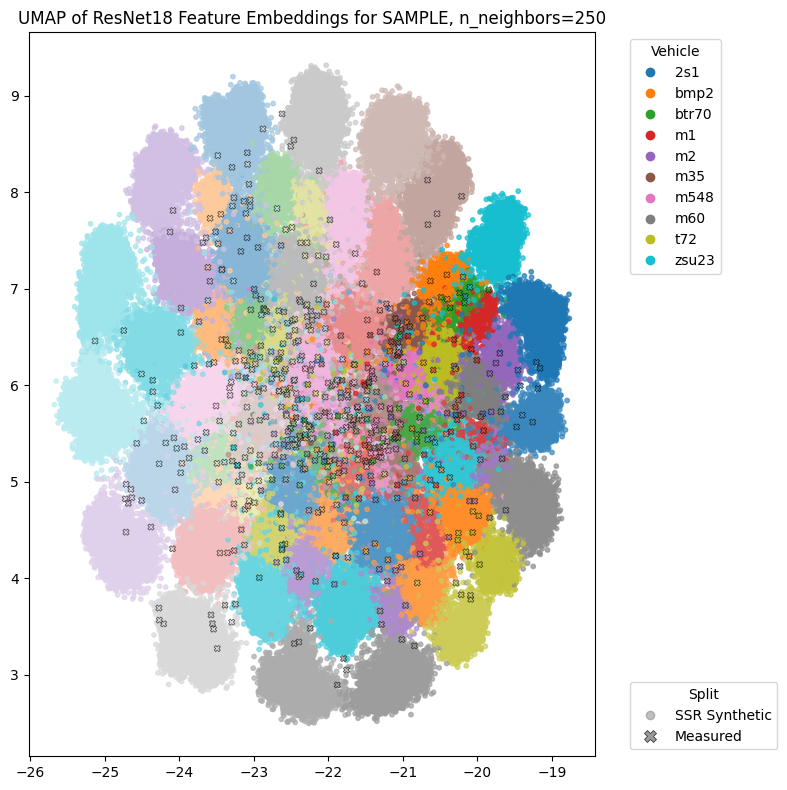

[2026-06-19 19:53:34.037] [CUML] [info] Building knn graph using nn descent (configured from build_algo='auto')
[2026-06-19 19:53:34.038] [CUML] [warning] to use nn descent as the build algo, nnd_graph_degree should be larger than or equal to n_neigbors. setting nnd_graph_degree to n_neighbors.
[2026-06-19 19:53:34.038] [CUML] [warning] to use nn descent as the build algo, nnd_intermediate_graph_degree should be larger than or equal to nnd_graph_degree. setting nnd_intermediate_graph_degree to nnd_graph_degree


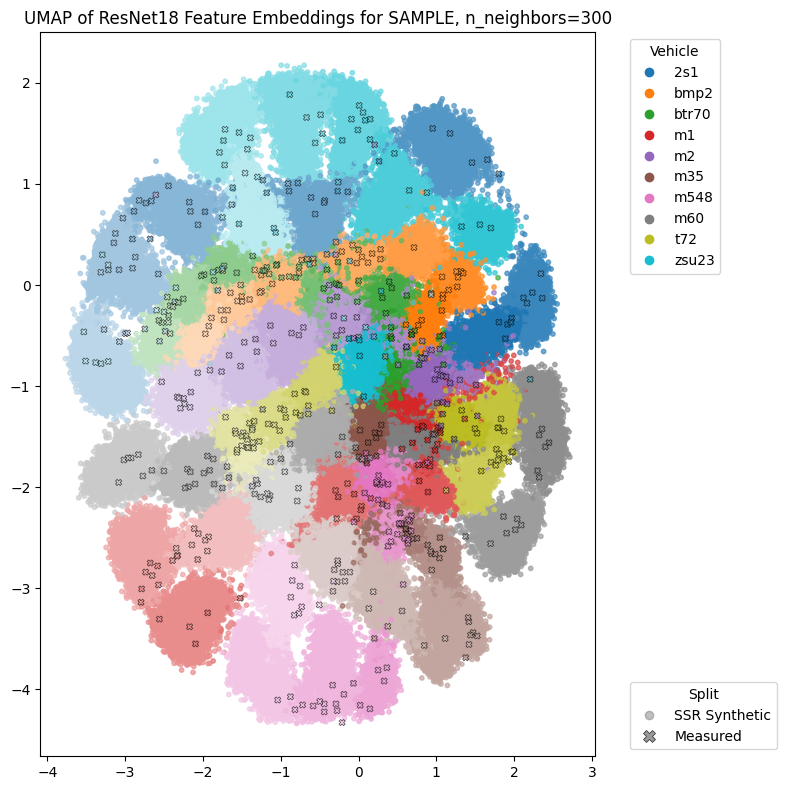

In [90]:
for num in [50, 100, 200, 250, 300]:
    set_seed(777)

    combined_feats = np.concatenate([SSR_synth_feats,  meas_feats],  axis=0)
    combined_labels = np.concatenate([SSR_synth_labels, meas_labels], axis=0)

    reducer = UMAP(
            n_neighbors=num,
            min_dist=0.25,
            n_components=2,
            metric = "cosine"
        )

    features_2d_umap = reducer.fit_transform(combined_feats)

    n_vehicles = len(new_SSR_synth_ds_14_15_16.dataset.classes)
    n_bins_per_vehicle = total_bins // n_vehicles 

    bin_colors = make_vehicle_bin_colors(n_vehicles, n_bins_per_vehicle)

    def labels_to_colors(label_array, bin_colors):
        return [bin_colors[l] for l in label_array]

    train_colors = labels_to_colors(combined_labels[:len(SSR_synth_feats)], bin_colors)
    test_colors  = labels_to_colors(combined_labels[len(SSR_synth_feats):], bin_colors)

    fig = plt.figure(figsize=(8, 8))
    scatter = plt.scatter(
        features_2d_umap[:len(SSR_synth_feats), 0],
        features_2d_umap[:len(SSR_synth_feats), 1],
        c=train_colors,
        s=10,
        alpha=0.7,
        marker = "o"
    )

    plt.scatter(
        features_2d_umap[len(SSR_synth_feats):, 0],
        features_2d_umap[len(SSR_synth_feats):, 1],
        c=test_colors,
        s=20,
        alpha=0.7,
        linewidths=0.5,
        marker = "X",
        edgecolors="k"
    )

    tab10 = plt.colormaps["tab10"]
    vehicle_handles = [
        Line2D([0], [0], marker="o", color=tab10(v), linestyle="None",
            markersize=6, label=new_SSR_synth_ds_14_15_16.dataset.classes[v])
        for v in range(n_vehicles)
    ]
    class_legend = plt.legend(handles=vehicle_handles, title="Vehicle",
                            bbox_to_anchor=(1.05, 1), loc="upper left")
    fig.add_artist(class_legend)

    marker_handles = [
        Line2D([0], [0], marker="o", color="grey", linestyle="None", markersize=6, alpha=0.5, label="SSR Synthetic"),
        Line2D([0], [0], marker="X", color="grey", linestyle="None", markersize=8, alpha=0.8, markeredgecolor="k", markeredgewidth=0.5, label="Measured"),
    ]
    plt.legend(handles=marker_handles, title="Split", bbox_to_anchor=(1.05, 0), loc="lower left")

    plt.title(f"UMAP of ResNet18 Feature Embeddings for SAMPLE, n_neighbors={num}")
    plt.tight_layout()
    plt.show()

[2026-06-19 20:04:34.383] [CUML] [info] Building knn graph using nn descent (configured from build_algo='auto')


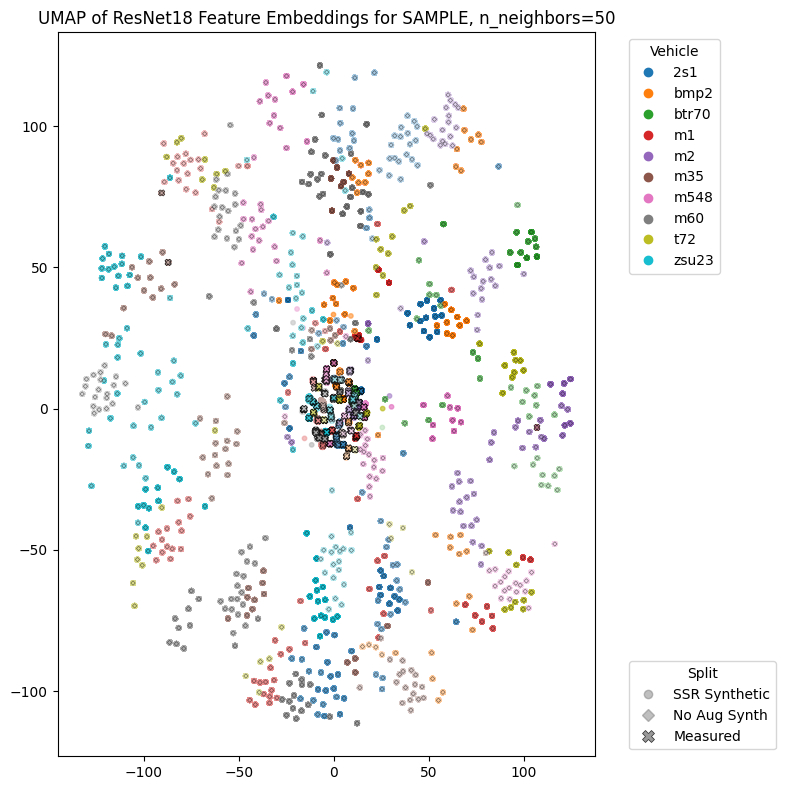

[2026-06-19 20:04:38.567] [CUML] [info] Building knn graph using nn descent (configured from build_algo='auto')
[2026-06-19 20:04:38.569] [CUML] [warning] to use nn descent as the build algo, nnd_graph_degree should be larger than or equal to n_neigbors. setting nnd_graph_degree to n_neighbors.


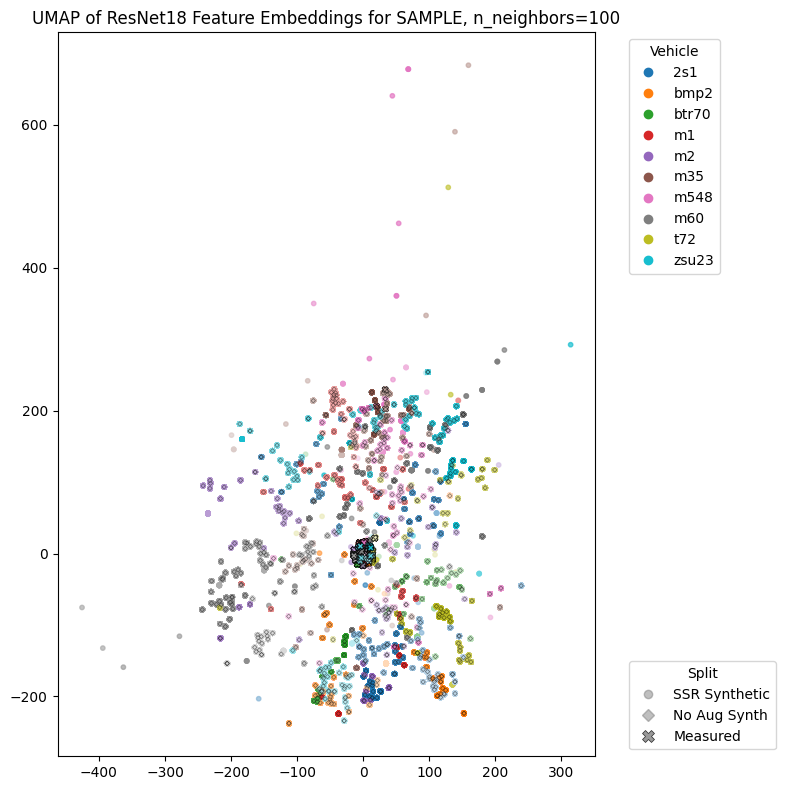

[2026-06-19 20:04:43.740] [CUML] [info] Building knn graph using nn descent (configured from build_algo='auto')
[2026-06-19 20:04:43.742] [CUML] [warning] to use nn descent as the build algo, nnd_graph_degree should be larger than or equal to n_neigbors. setting nnd_graph_degree to n_neighbors.
[2026-06-19 20:04:43.742] [CUML] [warning] to use nn descent as the build algo, nnd_intermediate_graph_degree should be larger than or equal to nnd_graph_degree. setting nnd_intermediate_graph_degree to nnd_graph_degree


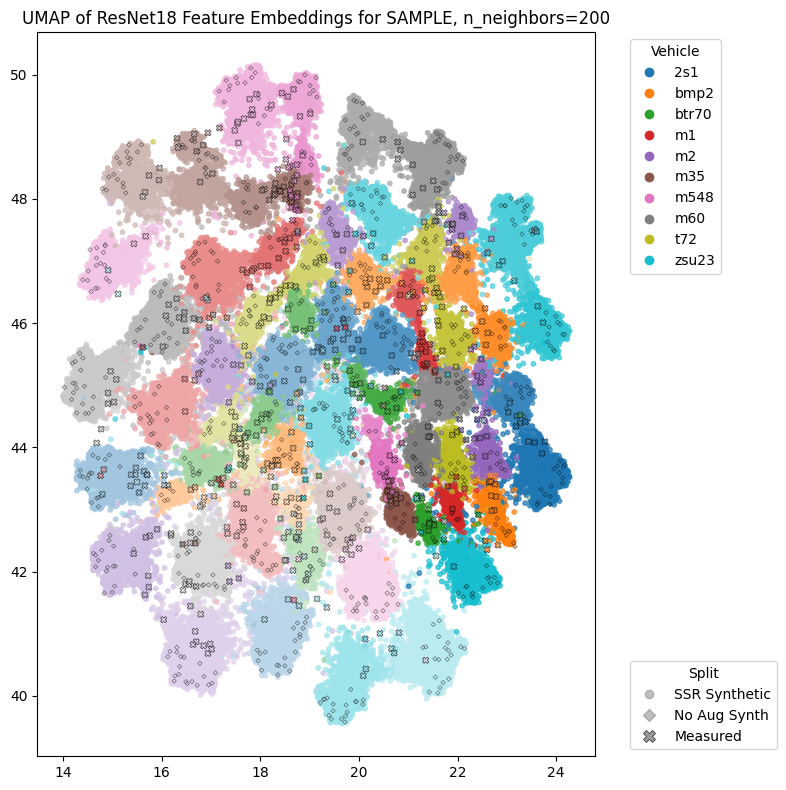

[2026-06-19 20:04:51.424] [CUML] [info] Building knn graph using nn descent (configured from build_algo='auto')
[2026-06-19 20:04:51.425] [CUML] [warning] to use nn descent as the build algo, nnd_graph_degree should be larger than or equal to n_neigbors. setting nnd_graph_degree to n_neighbors.
[2026-06-19 20:04:51.425] [CUML] [warning] to use nn descent as the build algo, nnd_intermediate_graph_degree should be larger than or equal to nnd_graph_degree. setting nnd_intermediate_graph_degree to nnd_graph_degree


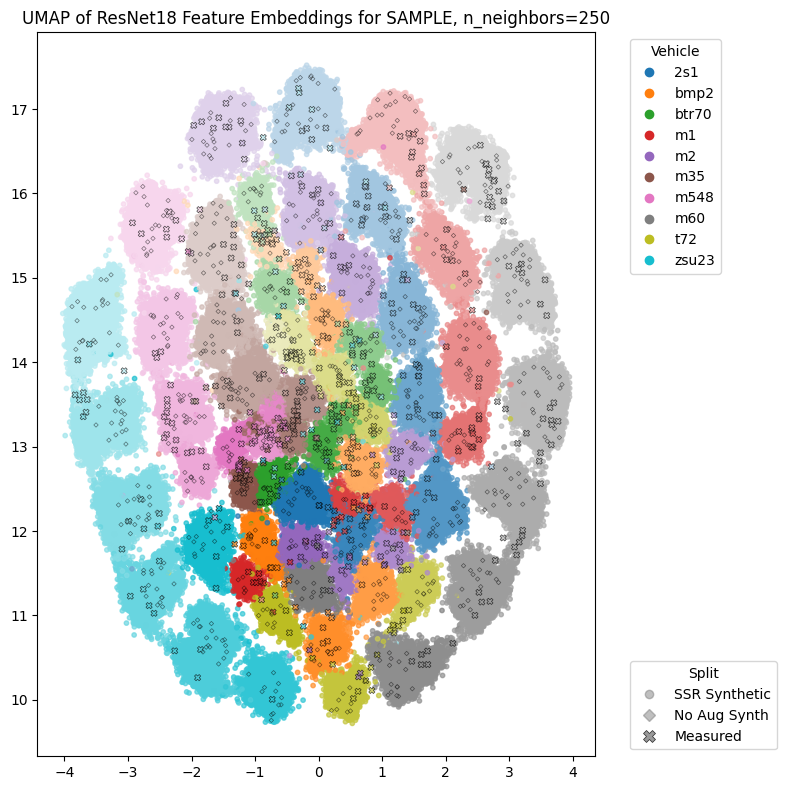

[2026-06-19 20:05:01.116] [CUML] [info] Building knn graph using nn descent (configured from build_algo='auto')
[2026-06-19 20:05:01.118] [CUML] [warning] to use nn descent as the build algo, nnd_graph_degree should be larger than or equal to n_neigbors. setting nnd_graph_degree to n_neighbors.
[2026-06-19 20:05:01.118] [CUML] [warning] to use nn descent as the build algo, nnd_intermediate_graph_degree should be larger than or equal to nnd_graph_degree. setting nnd_intermediate_graph_degree to nnd_graph_degree


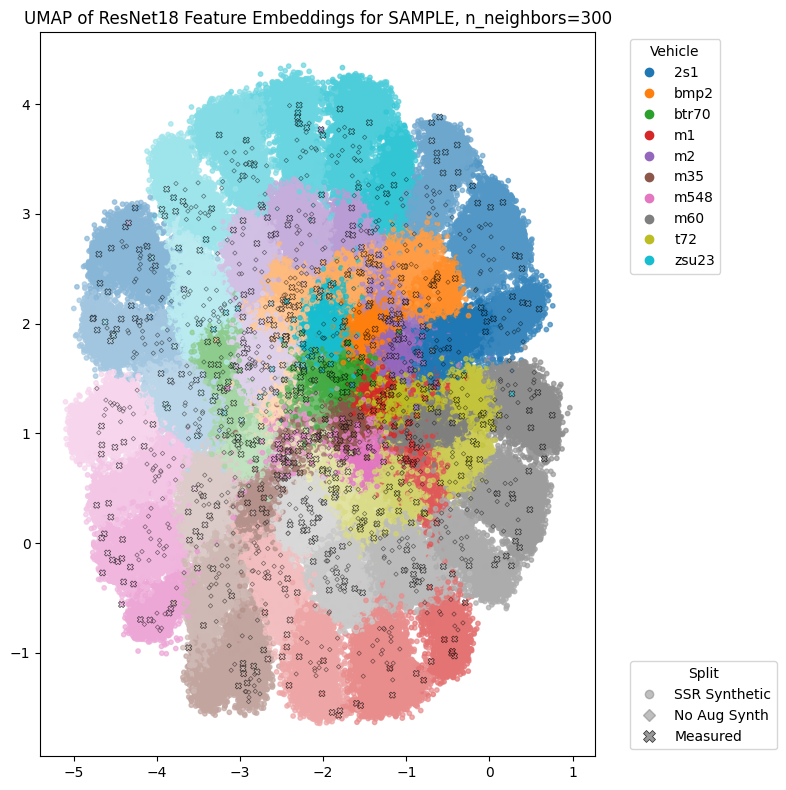

In [95]:
for num in [50, 100, 200, 250, 300]:
    set_seed(777)

    combined_feats = np.concatenate([SSR_synth_feats,  synth_feats, meas_feats],  axis=0)
    combined_labels = np.concatenate([SSR_synth_labels,  synth_labels, meas_labels], axis=0)

    reducer = UMAP(
            n_neighbors=num,
            min_dist=0.25,
            n_components=2,
            metric = "cosine"
        )

    features_2d_umap = reducer.fit_transform(combined_feats)

    n_vehicles = len(new_SSR_synth_ds_14_15_16.dataset.classes)
    n_bins_per_vehicle = total_bins // n_vehicles 

    bin_colors = make_vehicle_bin_colors(n_vehicles, n_bins_per_vehicle)

    def labels_to_colors(label_array, bin_colors):
        return [bin_colors[l] for l in label_array]

    train_colors = labels_to_colors(combined_labels[:len(SSR_synth_feats)], bin_colors)
    synth_colors = labels_to_colors(combined_labels[len(SSR_synth_feats):len(SSR_synth_feats) + len(synth_feats)], bin_colors)
    test_colors  = labels_to_colors(combined_labels[len(SSR_synth_feats) + len(synth_feats):], bin_colors)

    fig = plt.figure(figsize=(8, 8))
    scatter = plt.scatter(
        features_2d_umap[:len(SSR_synth_feats), 0],
        features_2d_umap[:len(SSR_synth_feats), 1],
        c=train_colors,
        s=10,
        alpha=0.7,
        marker = "o"
    )

    plt.scatter(
        features_2d_umap[len(SSR_synth_feats) + len(synth_feats):, 0],
        features_2d_umap[len(SSR_synth_feats) + len(synth_feats):, 1],
        c=test_colors,
        s=20,
        alpha=0.7,
        linewidths=0.5,
        marker = "X",
        edgecolors="k"
    )

    plt.scatter(
        features_2d_umap[len(SSR_synth_feats):len(SSR_synth_feats) + len(synth_feats), 0],
        features_2d_umap[len(SSR_synth_feats):len(SSR_synth_feats) + len(synth_feats), 1],
        c=synth_colors,
        s=5,
        alpha=0.5,
        linewidths=0.5,
        edgecolors="k",
        marker = "D"
    )

    tab10 = plt.colormaps["tab10"]
    vehicle_handles = [
        Line2D([0], [0], marker="o", color=tab10(v), linestyle="None",
            markersize=6, label=new_SSR_synth_ds_14_15_16.dataset.classes[v])
        for v in range(n_vehicles)
    ]
    class_legend = plt.legend(handles=vehicle_handles, title="Vehicle",
                            bbox_to_anchor=(1.05, 1), loc="upper left")
    fig.add_artist(class_legend)

    marker_handles = [
        Line2D([0], [0], marker="o", color="grey", linestyle="None", markersize=6, alpha=0.5, label="SSR Synthetic"),
        Line2D([0], [0], marker="D", color="grey", linestyle="None", markersize=6, alpha=0.5, label="No Aug Synth"),
        Line2D([0], [0], marker="X", color="grey", linestyle="None", markersize=8, alpha=0.8, markeredgecolor="k", markeredgewidth=0.5, label="Measured"),
    ]
    plt.legend(handles=marker_handles, title="Split", bbox_to_anchor=(1.05, 0), loc="lower left")

    plt.title(f"UMAP of ResNet18 Feature Embeddings for SAMPLE, n_neighbors={num}")
    plt.tight_layout()
    plt.show()

In [51]:
no_aug_synth_ds_14_15_16 = filter_by_elev(no_aug_synth_ds, {14, 15, 16})

s, b, total_bins, new_classes_train, new_to_old_classes_train = build_azimuth_bin_map(no_aug_synth_ds_14_15_16, bin_width=10)

new_no_aug_synth_ds_14_15_16 = AzimuthBinnedDataset(no_aug_synth_ds_14_15_16, s, new_classes_train)

meas_ds_17 = filter_by_elev(meas_ds, {17})
s, b, total_bins, new_classes_test, new_to_old_classes_test = build_azimuth_bin_map(meas_ds_17, bin_width=10)

new_meas_ds_17 = AzimuthBinnedDataset(meas_ds_17, s, new_classes_test)


device = torch.device("cuda:0")
seed_lst = [777]
for i, seed in enumerate(seed_lst):
    set_seed(seed)
    model = models.resnet18(weights = None) # dont load ImageNet Weights
    # new_model.fc = nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
    model.fc = nn.Sequential(
        nn.Dropout(p = 0.4),
        nn.Linear(model.fc.in_features, len(train_ds.classes))
    )
    # Load your trained weights
    model.load_state_dict(torch.load(
        os.path.join(workspace, f"weights/SSR/Extras/bins_10deg/SSR_w_noise/rn18_seed{seed}_b16.pth"),
        map_location=device
    ))

    # this gives the synth_features and synth_labels
    synth_features, synth_labels, _ = _get_features_and_preds_from_model(model, new_no_aug_synth_ds_14_15_16, device, seed)
    meas_features, meas_labels, meas_preds = _get_features_and_preds_from_model(model, new_meas_ds_17, device, seed)

    old_synth_labels = cp.array([new_to_old_classes_train[synth_labels[i].item()] for i in range(len(synth_labels))])
    old_meas_labels = cp.array([new_to_old_classes_test[meas_labels[i].item()] for i in range(len(meas_labels))])
    old_meas_preds = cp.array([new_to_old_classes_test[meas_preds[i].item()] for i in range(len(meas_preds))])

In [52]:
cosine_d_true_class, cosine_n_true_class = k_nearest_neighbors_by_true_class(
    meas_features, old_meas_labels, synth_features, old_synth_labels, metric = "cosine"
)

In [53]:
cosine_n_true_class

array([[ 75,   9,  74,  72,   2],
       [  3,   9,  69,   2,  70],
       [  3,  69,  70,   2,   9],
       ...,
       [802, 750, 749, 803, 747],
       [802, 750, 805, 749, 804],
       [749, 750, 802, 747, 803]], shape=(539, 5))

Class       q= 1  q= 3  q= 5
----------------------------
2s1         0.673  0.865  0.962  (n=52)
bmp2        0.647  0.843  0.922  (n=51)
btr70       0.604  0.875  0.917  (n=48)
m1          0.560  0.720  0.860  (n=50)
m2          0.580  0.920  0.960  (n=50)
m35         0.642  0.830  0.943  (n=53)
m548        0.810  0.881  0.976  (n=42)
m60         0.446  0.750  0.875  (n=56)
t72         0.647  0.863  0.922  (n=51)
zsu23       0.425  0.700  0.825  (n=40)
----------------------------
Overall     0.602  0.826  0.917  (n=493)
Class       q= 1  q= 3  q= 5
----------------------------
2s1         35.000  45.000  50.000  (n=52)
bmp2        33.000  43.000  47.000  (n=51)
btr70       29.000  42.000  44.000  (n=48)
m1          28.000  36.000  43.000  (n=50)
m2          29.000  46.000  48.000  (n=50)
m35         34.000  44.000  50.000  (n=53)
m548        34.000  37.000  41.000  (n=42)
m60         25.000  42.000  49.000  (n=56)
t72         33.000  44.000  47.000  (n=51)
zsu23       17.000  28.000 

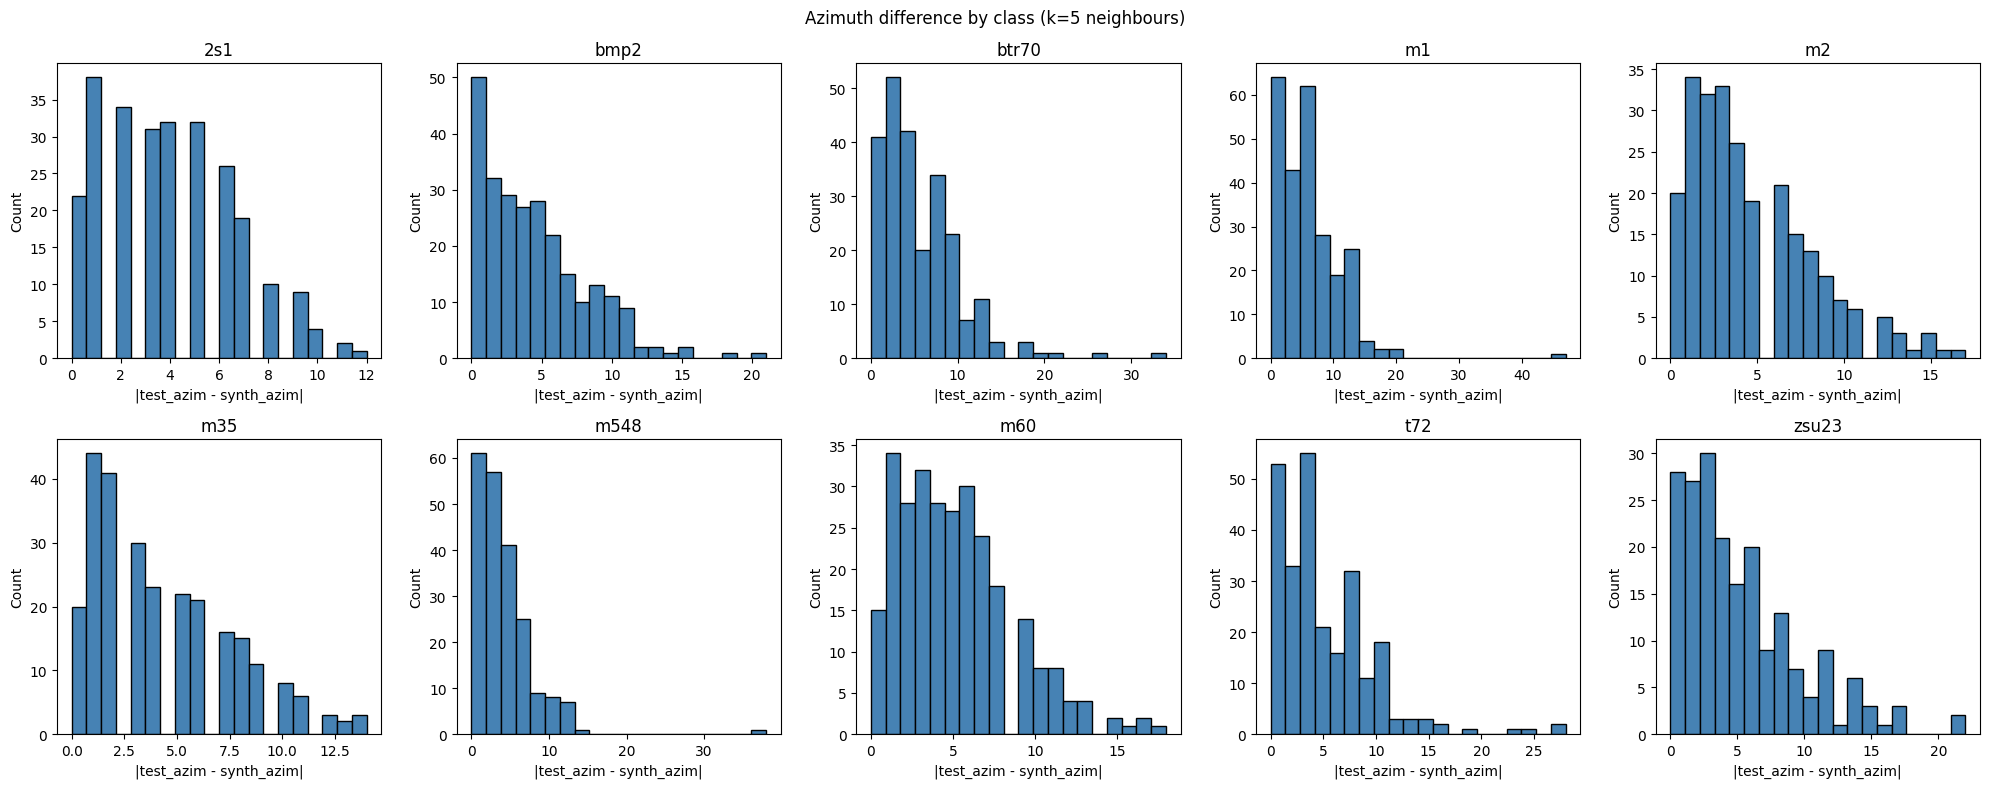

In [54]:
results, azim_diffs = azim_agreement_analysis_by_class(
    new_meas_ds_17.dataset, old_meas_labels, old_meas_preds,
    new_no_aug_synth_ds_14_15_16.dataset, cosine_n_true_class,
    q_values=[1, 3, 5],
    k = 5
)

results, azim_diffs = azim_agreement_analysis_by_class(
    new_meas_ds_17.dataset, old_meas_labels, old_meas_preds,
    new_no_aug_synth_ds_14_15_16.dataset, cosine_n_true_class,
    q_values=[1, 3, 5], k = 5, normalise = False
)

results, azim_diffs = cp.asnumpy(results), cp.asnumpy(azim_diffs)

correct_mask    = cp.asnumpy(old_meas_preds) == cp.asnumpy(old_meas_labels)
correct_classes = cp.asnumpy(old_meas_labels)[np.where(correct_mask)[0]]
plot_azim_diffs_by_class(new_meas_ds_17.dataset, azim_diffs, correct_classes)